# HFT Strategy Optimization: Exact vs. Metaheuristic Approaches

This notebook optimizes the parameters of a **High-Frequency Trading (HFT)** strategy on **real** Binance BTC/USDT tick data by comparing two fundamentally different optimization paradigms:

| | **Exact Optimization** | **Metaheuristic Optimization** |
|---|---|---|
| **Method** | Recursive Grid Search (Branch & Zoom) | Genetic Algorithm (PyGAD) |
| **Search Type** | Discretized, deterministic | Continuous, stochastic |
| **Strength** | Guarantees global optimum within grid resolution | Escapes local optima in non-convex landscapes |
| **Trade-off** | Exponential cost in high dimensions | No formal optimality guarantee |

---

## Objective Function

Maximize the annualized **Sharpe Ratio**:

$$
S = \frac{\mathbb{E}\!\left[R_p - R_f\right]}{\sigma_p}
$$

where $R_p$ is the portfolio return, $R_f$ is the risk-free rate, and $\sigma_p$ is the portfolio volatility.

> In the GA formulation this becomes a **fitness function** with additive penalty terms for constraint violations (see below).

---

## Decision Variables

| Variable | Description | Domain |
|:---:|---|---|
| $T$ | **Order Book Imbalance Threshold** - sensitivity to buy/sell pressure | $0.01 < T \leq 1.0$ |
| $L$ | **Stop-Loss** - maximum tolerable loss per trade | $0.1\% < L \leq 10.0\%$ |
| $P$ | **Take-Profit** - target gain per trade | $0.1\% < P \leq 20.0\%$ |

---

## Constraints

To ensure the optimized strategy is **robust and practically tradeable**, the following constraints are enforced (violated constraints incur penalties in the GA fitness function):

| Constraint | Condition | Rationale |
|---|---|---|
| **Risk Control** | Max Drawdown $\leq 10\%$ | Prevents catastrophic capital erosion |
| **Cost Efficiency** | Transaction Costs $\leq 20\%$ of Gross Profit | Ensures profitability net of fees |
| **Statistical Significance** | Trade Count $\geq 50$ round-trips | Guards against overfitting to sparse signals |

---

## Method Details

**Exact — Recursive Grid Search (Branch & Zoom)**
1. Evaluate a coarse grid over the full parameter space
2. Identify the best-performing region
3. Recursively refine the grid around that region (narrowing bounds each iteration)
4. Converges toward the global optimum within grid resolution

**Metaheuristic - Genetic Algorithm**
1. Initialize a diverse population of candidate parameter vectors
2. Evaluate fitness (penalized Sharpe) for each individual
3. Apply **tournament selection**, **crossover**, and **random mutation**
4. Iterate until convergence - explores the continuous space between grid points

---

## Section 1: Import Required Libraries

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
import time
from datetime import datetime
import os
import random
from pulp import LpProblem, LpMaximize, LpVariable, lpSum, value, PULP_CBC_CMD, LpStatus
import pygad
import requests
import zipfile
import io

# ── Reproducibility ──────────────────────────────────────────
SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
# ─────────────────────────────────────────────────────────────

warnings.filterwarnings('ignore')
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 6)

DATA_PATH = Path("data")

print("✓ All libraries imported successfully!")
print(f"✓ Global random seed set to {SEED} for reproducibility")

✓ All libraries imported successfully!
✓ Global random seed set to 42 for reproducibility


## Section 2: Load and Explore Dataset

In [20]:
def download_binance_aggtrades(symbol, date):
    """
    Downloads and extracts Binance AggTrades data for a specific symbol and date.
    
    Args:
        symbol (str): The trading pair (e.g., 'BTCUSDT').
        date (str): The date in 'YYYY-MM-DD' format.
    """
    
    base_url = "https://data.binance.vision/data/spot/daily/aggTrades"
    file_name = f"{symbol}-aggTrades-{date}.zip"
    url = f"{base_url}/{symbol}/{file_name}"
    
    save_path = DATA_PATH / file_name.replace(".zip", ".csv")


    if save_path.exists():
        print(f"✓ File already exists: {save_path}")
        return save_path

    print(f"📥 Downloading {symbol} data for {date}...")
    
    response = requests.get(url, verify=False)
    
    if response.status_code == 200:
        with zipfile.ZipFile(io.BytesIO(response.content)) as z:
            z.extractall(DATA_PATH)
            print(f"✓ Downloaded and extracted to {save_path}")
            return save_path
    else:
        print(f"Failed to download. Status Code: {response.status_code}")
        print("Check if the symbol and date are correct.")
        return None

In [21]:
def process_binance_aggtrades(csv_path):
    """
    Loads Binance AggTrades data and engineers it to fit our HFT Backtester.
    Binance columns: [agg_trade_id, price, quantity, first_id, last_id, timestamp, is_buyer_maker, is_best_match]
    """
    print(f"Loading Binance data from {csv_path}...")
    
    cols = ['agg_id', 'price', 'quantity', 'first_id', 'last_id', 'timestamp', 'is_buyer_maker', 'is_best_match']
    df = pd.read_csv(csv_path, names=cols, header=None)
    
    df['timestamp'] = pd.to_datetime(df['timestamp'], unit='ms') 
    df.set_index('timestamp', inplace=True)
    
    df['sell_volume'] = np.where(df['is_buyer_maker'] == True, df['quantity'], 0)
    df['buy_volume']  = np.where(df['is_buyer_maker'] == False, df['quantity'], 0)
    
    df_1s = df.resample('1s').agg({
        'price': 'last',           
        'buy_volume': 'sum',       
        'sell_volume': 'sum'      
    }).dropna()
    
    df_1s.rename(columns={'price': 'mid_price'}, inplace=True)
    
    df_1s['mid_price_returns'] = df_1s['mid_price'].pct_change().fillna(0)
    
    total_volume = df_1s['buy_volume'] + df_1s['sell_volume']
    total_volume = total_volume.replace(0, np.nan) 
    
    df_1s['order_book_imbalance'] = (
        (df_1s['buy_volume'] - df_1s['sell_volume']) / total_volume
    ).fillna(0).clip(-1, 1)
    
    df_1s.reset_index(inplace=True)
    
    return df_1s

In [22]:
def generate_synthetic_crypto_data(n_samples=5000, seed=SEED):
    """
    Generate synthetic cryptocurrency tick data for backtesting.
    """

    random.seed(seed)
    np.random.seed(seed)
    timestamps = pd.date_range('2024-01-01', periods=n_samples, freq='1s')
    base_price = 50000
    returns = np.random.normal(0.00001, 0.0005, n_samples)
    prices = base_price * np.exp(np.cumsum(returns))
    spread = prices * 0.0002
    bid_prices = prices - spread / 2
    ask_prices = prices + spread / 2
    bid_volume = np.abs(np.random.normal(100, 50, n_samples))
    ask_volume = np.abs(np.random.normal(100, 50, n_samples))

    imbalance_signal = (bid_volume - ask_volume) / (bid_volume + ask_volume)
    bid_volume = bid_volume * (1 + 0.5 * imbalance_signal)
    ask_volume = ask_volume * (1 - 0.5 * imbalance_signal)

    df = pd.DataFrame({
        'timestamp': timestamps,
        'bid_price': bid_prices,
        'ask_price': ask_prices,
        'bid_volume': bid_volume,
        'ask_volume': ask_volume
    })
    return df

In [23]:
def engineer_features(df):
    """
    Engineer features for the HFT strategy based on order book imbalance.
    
    Features:
    - mid_price: (bid + ask) / 2
    - order_book_imbalance: (bid_vol - ask_vol) / (bid_vol + ask_vol)
    - returns: Log returns of mid price
    - cumulative_returns: Cumulative product of (1 + returns)
    """
    df = df.copy()
    
    df['mid_price'] = (df['bid_price'] + df['ask_price']) / 2
    
    df['order_book_imbalance'] = (df['bid_volume'] - df['ask_volume']) / (
        df['bid_volume'] + df['ask_volume']
    )
    
    df['mid_price_returns'] = np.log(df['mid_price'] / df['mid_price'].shift(1))
    df['mid_price_returns'].fillna(0, inplace=True)
    
    df['cumulative_returns'] = (1 + df['mid_price_returns']).cumprod()
    
    df['spread_bps'] = ((df['ask_price'] - df['bid_price']) / df['mid_price']) * 10000
    
    print("✓ Features engineered successfully")
    print(f"\nFeature statistics:")
    print(df[['mid_price', 'order_book_imbalance', 'mid_price_returns', 'spread_bps']].describe())
    
    return df

✓ File already exists: data\BTCUSDT-aggTrades-2024-01-01.csv
✓ Real data found at data\BTCUSDT-aggTrades-2024-01-01.csv. Processing...
Loading Binance data from data\BTCUSDT-aggTrades-2024-01-01.csv...

Final Dataset shape: (81947, 6)

First few rows:
            timestamp  mid_price  buy_volume  sell_volume  mid_price_returns  \
0 2024-01-01 00:00:00   42283.58     0.01658      0.05967       0.000000e+00   
1 2024-01-01 00:00:01   42283.58     0.75683      0.61845       0.000000e+00   
2 2024-01-01 00:00:02   42283.58     0.00124      0.18743       0.000000e+00   
3 2024-01-01 00:00:03   42283.59     0.51935      0.31553       2.364984e-07   
4 2024-01-01 00:00:04   42283.59     0.03653      0.20156       0.000000e+00   
5 2024-01-01 00:00:05   42276.84     0.29445      2.15701      -1.596364e-04   
6 2024-01-01 00:00:06   42273.21     0.38302      0.32796      -8.586261e-05   
7 2024-01-01 00:00:07   42269.53     0.22577      0.82550      -8.705277e-05   
8 2024-01-01 00:00:08   4226

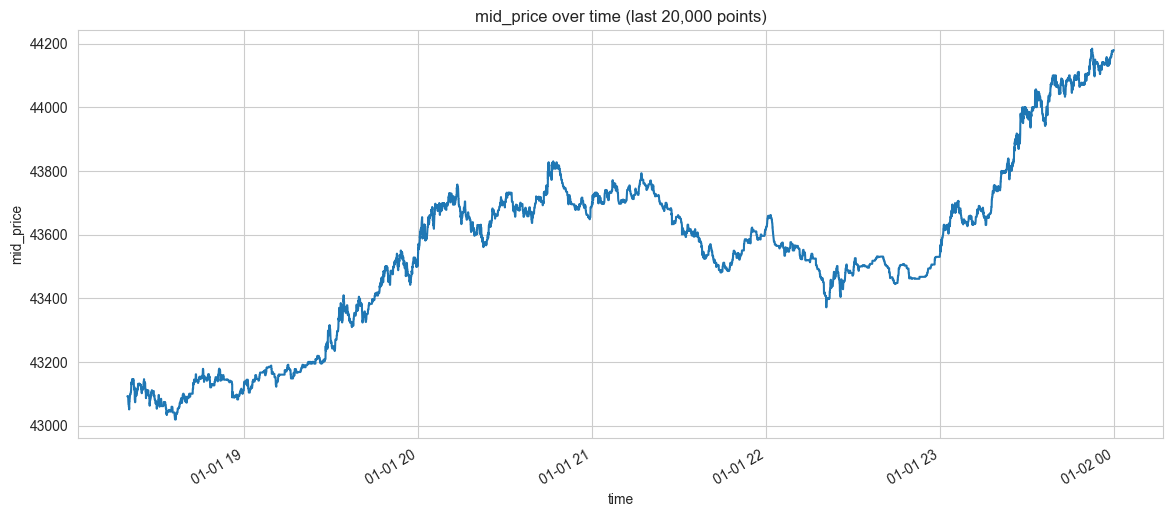

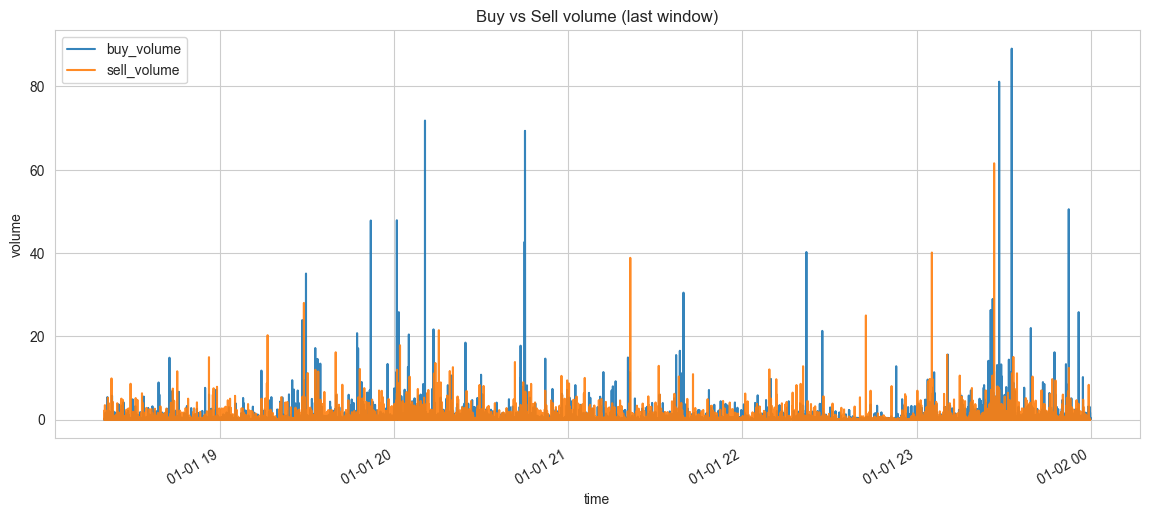

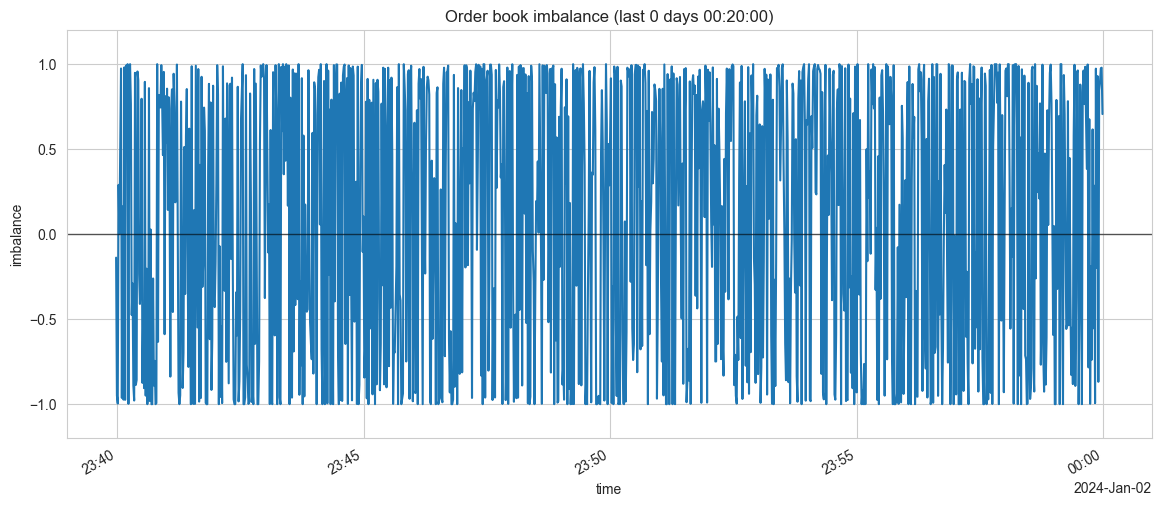

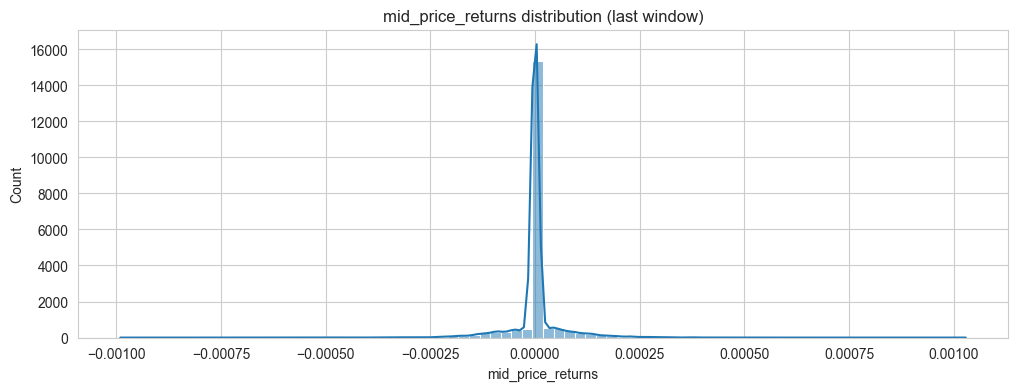

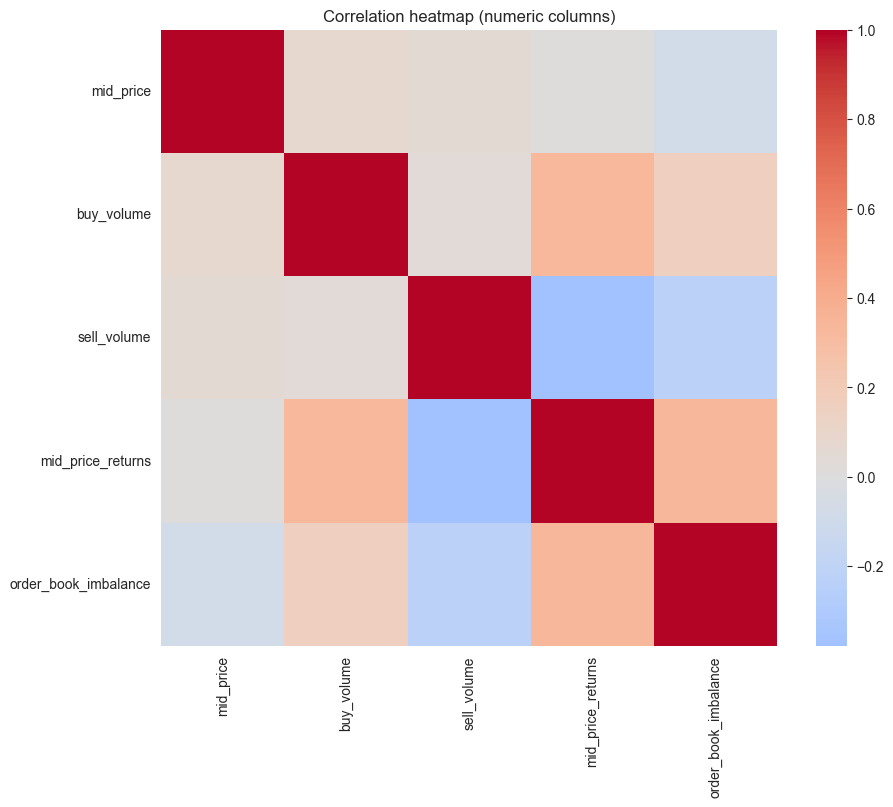

In [24]:
DATA_FILE_PATH = download_binance_aggtrades("BTCUSDT", "2024-01-01")

if DATA_FILE_PATH and DATA_FILE_PATH.exists():
    print(f"✓ Real data found at {DATA_FILE_PATH}. Processing...")
    df = process_binance_aggtrades(DATA_FILE_PATH)
else:
    print("⚠ Real data not found or download failed. Falling back to synthetic data...")
    df = generate_synthetic_crypto_data(n_samples=5000)
    
    df = engineer_features(df) 
    
    SYNTH_PATH = DATA_PATH / "synthetic_crypto_data.csv"
    df.to_csv(SYNTH_PATH, index=False)
    print(f"✓ Synthetic data generated and saved to {SYNTH_PATH}")

print(f"\nFinal Dataset shape: {df.shape}")
print(f"\nFirst few rows:")
print(df.head(10))
print(f"\nData types:")
print(df.dtypes)
print(f"\nBasic statistics:")
print(df.describe())

df_plot = df.copy()

# Put time on the index when possible
if 'timestamp' in df_plot.columns:
    df_plot['timestamp'] = pd.to_datetime(df_plot['timestamp'], errors='coerce')
    df_plot = df_plot.sort_values('timestamp')
    df_plot = df_plot.set_index('timestamp')
elif isinstance(df_plot.index, pd.DatetimeIndex):
    df_plot = df_plot.sort_index()

# Pick a price-like column
price_col = 'mid_price' if 'mid_price' in df_plot.columns else ('price' if 'price' in df_plot.columns else None)
if price_col is None:
    numeric_cols = df_plot.select_dtypes(include='number').columns.tolist()
    price_col = numeric_cols[0] if numeric_cols else None

# Ensure returns exist for distribution plot
if 'mid_price_returns' not in df_plot.columns and price_col is not None:
    df_plot['mid_price_returns'] = df_plot[price_col].pct_change()

# Limit plotted points so notebooks stay responsive
max_points = 20_000
if len(df_plot) > max_points:
    df_vis = df_plot.iloc[-max_points:].copy()
else:
    df_vis = df_plot.copy()

# 1) Price over time
if price_col is not None:
    ax = df_vis[price_col].plot(title=f"{price_col} over time (last {len(df_vis):,} points)")
    ax.set_xlabel("time")
    ax.set_ylabel(price_col)
    plt.show()

# 2) Volume over time (buy vs sell when available)
if 'buy_volume' in df_vis.columns and 'sell_volume' in df_vis.columns:
    ax = df_vis[['buy_volume', 'sell_volume']].plot(title="Buy vs Sell volume (last window)", alpha=0.9)
    ax.set_xlabel("time")
    ax.set_ylabel("volume")
    plt.show()
else:
    vol_cols = [c for c in ['quantity', 'volume'] if c in df_vis.columns]
    if len(vol_cols) > 0:
        ax = df_vis[vol_cols].plot(title="Volume-related columns (last window)", alpha=0.9)
        ax.set_xlabel("time")
        plt.show()

# 3) Order book imbalance over time (if present)
if 'order_book_imbalance' in df_vis.columns:
    s_all = df_vis['order_book_imbalance'].dropna()

    # Full resolution, but plot a shorter time window
    period = pd.Timedelta("20min")  # change to "2H" / "10min" etc.
    if isinstance(s_all.index, pd.DatetimeIndex) and len(s_all) > 0:
        start = s_all.index.max() - period
        s = s_all.loc[start:]
    else:
        # fallback: last N rows when no datetime index (~30 min if 1-second)
        s = s_all.tail(1800)

    ax = s.plot(title=f"Order book imbalance (last {period})")
    ax.set_xlabel("time")
    ax.set_ylabel("imbalance")
    plt.axhline(0, color='black', linewidth=1, alpha=0.6)

    # Zoom y-axis using robust quantiles so the plot is readable
    if len(s) > 10:
        q_low, q_high = s.quantile([0.01, 0.99])
        if np.isfinite(q_low) and np.isfinite(q_high) and q_low != q_high:
            pad = 0.10 * (q_high - q_low)
            ax.set_ylim(q_low - pad, q_high + pad)

    # Make datetime x-axis ticks readable
    if isinstance(s.index, pd.DatetimeIndex):
        import matplotlib.dates as mdates
        locator = mdates.AutoDateLocator(minticks=4, maxticks=8)
        ax.xaxis.set_major_locator(locator)
        ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(locator))
        plt.gcf().autofmt_xdate()

    plt.show()

# 4) Returns distribution
if 'mid_price_returns' in df_vis.columns:
    plt.figure(figsize=(12, 4))
    sns.histplot(df_vis['mid_price_returns'].dropna(), bins=80, kde=True)
    plt.title("mid_price_returns distribution (last window)")
    plt.xlabel("mid_price_returns")
    plt.show()

# 5) Correlation heatmap (numeric columns)
num = df_vis.select_dtypes(include='number')
if num.shape[1] >= 2:
    corr = num.corr()
    plt.figure(figsize=(10, 8))
    sns.heatmap(corr, cmap="coolwarm", center=0, square=True)
    plt.title("Correlation heatmap (numeric columns)")
    plt.show()

## Section 3: Exploratory Data Analysis (EDA)

Before optimizing, we explore the dataset to understand its statistical properties, identify patterns in order-book dynamics, and validate that the data is suitable for backtesting an HFT strategy.

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(20, 10))
fig.suptitle('Exploratory Data Analysis — BTC/USDT Tick Data', fontsize=16, fontweight='bold')

# 1 — Mid price time series
ax = axes[0, 0]
ax.plot(df['timestamp'], df['mid_price'], linewidth=0.6, color='#2563eb')
ax.set_title('Mid Price Over Time', fontweight='bold')
ax.set_xlabel('Time')
ax.set_ylabel('Price (USDT)')
ax.tick_params(axis='x', rotation=30)

# 2 — Return distribution with normal overlay
ax = axes[0, 1]
rets = df['mid_price_returns'].dropna()
ax.hist(rets, bins=100, density=True, alpha=0.7, color='#7c3aed', edgecolor='white')
x_range = np.linspace(rets.min(), rets.max(), 200)
from scipy.stats import norm
mu, sigma = rets.mean(), rets.std()
ax.plot(x_range, norm.pdf(x_range, mu, sigma), 'r-', linewidth=2, label=f'Normal($\mu$={mu:.2e}, $\sigma$={sigma:.2e})')
ax.set_title('Return Distribution vs Normal', fontweight='bold')
ax.set_xlabel('1-Second Return')
ax.set_ylabel('Density')
ax.legend(fontsize=8)

# 3 — Order book imbalance distribution
ax = axes[0, 2]
ax.hist(df['order_book_imbalance'], bins=80, alpha=0.7, color='#059669', edgecolor='white')
ax.axvline(x=0, color='red', linestyle='--', linewidth=1.5)
ax.set_title('Order Book Imbalance Distribution', fontweight='bold')
ax.set_xlabel('Imbalance (buy−sell) / total')
ax.set_ylabel('Frequency')

# 4 — Rolling volatility (60-second window)
ax = axes[1, 0]
rolling_vol = df['mid_price_returns'].rolling(window=60).std() * np.sqrt(86400) * 100
ax.plot(df['timestamp'], rolling_vol, linewidth=0.5, color='#dc2626')
ax.set_title('Rolling Volatility (60s window, annualized %)', fontweight='bold')
ax.set_xlabel('Time')
ax.set_ylabel('Volatility (%)')
ax.tick_params(axis='x', rotation=30)

# 5 — Autocorrelation of returns
ax = axes[1, 1]
max_lag = 30
autocorrs = [rets.autocorr(lag=i) for i in range(1, max_lag + 1)]
ax.bar(range(1, max_lag + 1), autocorrs, color='#f59e0b', edgecolor='white', alpha=0.8)
ax.axhline(y=0, color='black', linewidth=0.8)
ax.axhline(y=1.96/np.sqrt(len(rets)), color='blue', linestyle='--', linewidth=1, alpha=0.6, label='95% CI')
ax.axhline(y=-1.96/np.sqrt(len(rets)), color='blue', linestyle='--', linewidth=1, alpha=0.6)
ax.set_title('Return Autocorrelation (Lag 1–30)', fontweight='bold')
ax.set_xlabel('Lag (seconds)')
ax.set_ylabel('Autocorrelation')
ax.legend(fontsize=9)

# 6 — Buy vs Sell volume over time (rolling 300s)
ax = axes[1, 2]
if 'buy_volume' in df.columns and 'sell_volume' in df.columns:
    roll_buy = df['buy_volume'].rolling(300).sum()
    roll_sell = df['sell_volume'].rolling(300).sum()
    ax.plot(df['timestamp'], roll_buy, label='Buy Volume', color='#22c55e', linewidth=0.8)
    ax.plot(df['timestamp'], roll_sell, label='Sell Volume', color='#ef4444', linewidth=0.8)
    ax.set_title('Rolling Buy vs Sell Volume (5-min)', fontweight='bold')
    ax.set_xlabel('Time')
    ax.set_ylabel('Volume (BTC)')
    ax.legend(fontsize=9)
    ax.tick_params(axis='x', rotation=30)
else:
    ax.text(0.5, 0.5, 'Volume columns\nnot available', ha='center', va='center', fontsize=12, transform=ax.transAxes)
    ax.set_title('Buy vs Sell Volume', fontweight='bold')

plt.tight_layout()
plt.show()

# Summary statistics table
print("\n" + "=" * 70)
print("DATASET SUMMARY STATISTICS")
print("=" * 70)
summary_cols = ['mid_price', 'mid_price_returns', 'order_book_imbalance']
if 'buy_volume' in df.columns:
    summary_cols += ['buy_volume', 'sell_volume']
print(df[summary_cols].describe().round(6).to_string())
print(f"\nDataset shape: {df.shape[0]:,} rows x {df.shape[1]} columns")
print(f"Time span: {df['timestamp'].iloc[0]} to {df['timestamp'].iloc[-1]}")
print(f"Return kurtosis: {rets.kurtosis():.2f} (Normal = 3.0 → heavy tails indicate non-normality)")
print(f"Return skewness: {rets.skew():.4f}")
print("=" * 70)

## Section 3b: Formal Mathematical Formulation

### Problem Class

This problem belongs to the class of **black-box parameter optimization** over a non-convex, non-differentiable objective. The objective function (Sharpe Ratio) is computed via a backtesting simulation, making it impossible to express in closed form — the landscape is noisy, discontinuous, and potentially multimodal. This makes the problem **NP-hard** in the general case (no polynomial-time algorithm can guarantee the global optimum).

---

### Notation

Let $\mathbf{x} = (T, L, P) \in \mathbb{R}^3$ denote the decision vector, where:

| Symbol | Variable | Domain | Unit |
|:---:|---|---|---|
| $T$ | Order Book Imbalance Threshold | $(0.01,\; 1.0]$ | — |
| $L$ | Stop-Loss | $(0.1,\; 10.0]$ | % |
| $P$ | Take-Profit | $(0.1,\; 20.0]$ | % |

---

### Objective Function

Given a dataset $\mathcal{D}$ of $N$ time-stamped price observations, define the **backtesting simulator** $\text{BT}(\mathbf{x}; \mathcal{D})$ which returns a vector of $N$ net strategy returns $\{r_t\}_{t=1}^{N}$.

The **annualized Sharpe Ratio** is:

$$
S(\mathbf{x}) \;=\; \frac{\bar{r}(\mathbf{x})}{\sigma_r(\mathbf{x})} \;\times\; \sqrt{B \times 365}
$$

where:
- $\bar{r}(\mathbf{x}) = \frac{1}{N}\sum_{t=1}^{N} r_t(\mathbf{x})$ is the mean per-bar net return
- $\sigma_r(\mathbf{x}) = \sqrt{\frac{1}{N}\sum_{t=1}^{N}\bigl(r_t(\mathbf{x}) - \bar{r}(\mathbf{x})\bigr)^2}$ is the standard deviation
- $B$ = bars per day (86,400 for 1-second data)

---

### Optimization Problem

$$
\begin{aligned}
\max_{\mathbf{x}} \quad & S(\mathbf{x}) \\[6pt]
\text{subject to:} \quad
& \text{MaxDD}(\mathbf{x}) \;\leq\; 10\% && \text{(risk control)} \\
& \text{TC}(\mathbf{x}) \;\leq\; 0.20 \times |\text{GP}(\mathbf{x})| && \text{(cost efficiency)} \\
& n_{\text{trades}}(\mathbf{x}) \;\geq\; 50 && \text{(statistical significance)} \\
& T \in (0.01, 1.0], \;\; L \in (0.1, 10.0], \;\; P \in (0.1, 20.0]
\end{aligned}
$$

where:
- $\text{MaxDD}(\mathbf{x}) = \max_{t}\left(1 - \frac{E_t(\mathbf{x})}{\max_{s \leq t} E_s(\mathbf{x})}\right)$ is the maximum drawdown of the equity curve $E_t$
- $\text{TC}(\mathbf{x})$ = total transaction costs (proportional to position turnover)
- $\text{GP}(\mathbf{x})$ = gross profit before costs
- $n_{\text{trades}}(\mathbf{x})$ = number of round-trip trades

---

### Constraint Handling

| Method | Approach |
|---|---|
| **Branch & Bound (Exact)** | Feasibility is checked *after* evaluation; infeasible points receive a soft penalty to the score, allowing the search to still orient toward feasible regions |
| **Genetic Algorithm (Metaheuristic)** | Constraints are embedded *into* the fitness function via additive penalties: $f(\mathbf{x}) = S(\mathbf{x}) - \lambda_1 \cdot v_{\text{DD}} - \lambda_2 \cdot v_{\text{cost}} - \lambda_3 \cdot v_{\text{trades}}$ where $v_i$ are violation magnitudes |

## Section 4: Calculate Strategy Performance Metrics

In [25]:
def _infer_bars_per_day(df, timestamp_col='timestamp', default_bars_per_day=24 * 3600):
    """Infer bars/day from timestamps; fallback to 1-second bars."""
    try:
        if timestamp_col in df.columns:
            ts = pd.to_datetime(df[timestamp_col], errors='coerce')
        else:
            ts = df.index if isinstance(df.index, pd.DatetimeIndex) else None

        if ts is None:
            return default_bars_per_day

        ts = ts.dropna()
        if len(ts) < 3:
            return default_bars_per_day

        dt = ts.sort_values().diff().dropna().dt.total_seconds()
        bar_seconds = float(dt.median())
        if not np.isfinite(bar_seconds) or bar_seconds <= 0:
            return default_bars_per_day

        return int(round(86400 / bar_seconds))
    except Exception:
        return default_bars_per_day


def backtest_strategy_vectorized(
    df,
    threshold,
    stop_loss,
    take_profit,
    transaction_cost_pct=0.0001,
    bars_per_day=None,
    timestamp_col='timestamp',
    return_df=False,
):
    df = df.copy()

    if 'mid_price_returns' not in df.columns:
        df['mid_price_returns'] = df['mid_price'].pct_change().fillna(0)

    df['imbalance_smoothed'] = (
        df['order_book_imbalance']
        .rolling(window=5, min_periods=1)
        .mean()
        .fillna(0)
    )

    # Raw (sparse) entry signals
    raw = np.zeros(len(df), dtype=float)
    imb = df['imbalance_smoothed']

    long_entry = (imb > threshold) & (imb.shift(1) > threshold)
    short_entry = (imb < -threshold) & (imb.shift(1) < -threshold)

    raw[long_entry.values] = 1
    raw[short_entry.values] = -1

    # Flat zone: explicitly exit when imbalance is small
    flat_zone = imb.abs() < 0.05
    raw[flat_zone.values] = 0

    position = pd.Series(raw, index=df.index, name='position')
    position = position.replace(0, np.nan).ffill().fillna(0)

    # Stop-loss / take-profit applied per trade segment
    if stop_loss > 0 or take_profit > 0:
        trade_id = (position != position.shift(1)).cumsum()
        trade_ret = position.shift(1).fillna(0) * df['mid_price_returns']
        cum_trade_ret = trade_ret.groupby(trade_id).cumsum()

        sl_limit = -stop_loss / 100.0
        tp_limit = take_profit / 100.0

        breach = pd.Series(False, index=df.index)
        if stop_loss > 0:
            breach |= cum_trade_ret <= sl_limit
        if take_profit > 0:
            breach |= cum_trade_ret >= tp_limit

        force_exit = breach.groupby(trade_id).cummax()
        position = position.mask(force_exit, 0)

    # PnL + costs
    df['position'] = position
    df['strategy_return'] = (df['position'].shift(1).fillna(0) * df['mid_price_returns']).fillna(0)
    df['position_change'] = df['position'].diff().abs().fillna(0)
    df['transaction_cost'] = df['position_change'] * transaction_cost_pct
    df['net_return'] = df['strategy_return'] - df['transaction_cost']

    # Correct compounding for equity curve
    df['equity'] = (1 + df['net_return']).cumprod()
    df['running_max'] = df['equity'].cummax()
    df['drawdown'] = df['equity'] / df['running_max'] - 1

    max_drawdown = float((-df['drawdown'].min()) * 100) if len(df) else 0.0

    # Sharpe with frequency-aware scaling
    net_rets = df['net_return'].to_numpy(dtype=float)
    valid_returns = net_rets[np.isfinite(net_rets)]

    if bars_per_day is None:
        bars_per_day = _infer_bars_per_day(df, timestamp_col=timestamp_col)

    if len(valid_returns) == 0 or float(np.std(valid_returns)) == 0.0:
        sharpe_ratio = -10.0
    else:
        mean_bar = float(np.mean(valid_returns))
        std_bar = float(np.std(valid_returns))
        sharpe_ratio = (mean_bar / std_bar) * np.sqrt(bars_per_day * 365) if std_bar > 0 else -10.0

    # Trade counting + win-rate (handles flips cleanly)
    pos = df['position'].fillna(0)
    prev = pos.shift(1).fillna(0)

    entry = (pos != 0) & (prev == 0)
    flip = (pos != 0) & (prev != 0) & (np.sign(pos) != np.sign(prev))
    num_trades = int((entry | flip).sum())

    trade_groups = (pos != prev).cumsum()
    trade_returns = df.groupby(trade_groups)['strategy_return'].sum()
    is_active = df.groupby(trade_groups)['position'].first() != 0
    real_trade_returns = trade_returns[is_active]

    wins = int((real_trade_returns > 0).sum())
    win_rate = (wins / len(real_trade_returns) * 100) if len(real_trade_returns) else 0.0

    results = {
        'sharpe_ratio': float(sharpe_ratio),
        'max_drawdown': float(max_drawdown),
        'gross_profit': float(df['strategy_return'].sum() * 100),
        'transaction_costs': float(df['transaction_cost'].sum() * 100),
        'net_profit': float((df['equity'].iloc[-1] - 1) * 100) if len(df) else 0.0,
        'num_trades': num_trades,
        'threshold': float(threshold),
        'stop_loss': float(stop_loss),
        'take_profit': float(take_profit),
        'win_rate': float(win_rate),
        'bars_per_day': int(bars_per_day),
    }

    if return_df:
        return results, df

    return results


print("Testing improved vectorized backtest function:")
print("Threshold=0.93, Stop-loss=2.0%, Take-profit=5.0%\n")

test_results, test_df = backtest_strategy_vectorized(
    df,
    threshold=0.93,
    stop_loss=2.0,
    take_profit=5.0,
    return_df=True,
)

print(f"Sharpe Ratio: {test_results['sharpe_ratio']:.4f}")
print(f"Gross Profit: {test_results['gross_profit']:.2f}%")
print(f"Transaction Costs: {test_results['transaction_costs']:.2f}%")
print(f"Net Profit: {test_results['net_profit']:.2f}%")
print(f"Max Drawdown: {test_results['max_drawdown']:.2f}%")
print(f"Number of Trades: {test_results['num_trades']}")
print(f"Win Rate: {test_results['win_rate']:.2f}%")
print(f"Bars per day (inferred): {test_results['bars_per_day']}")

Testing improved vectorized backtest function:
Threshold=0.93, Stop-loss=2.0%, Take-profit=5.0%

Sharpe Ratio: -2.2484
Gross Profit: 3.22%
Transaction Costs: 3.37%
Net Profit: -0.16%
Max Drawdown: 3.04%
Number of Trades: 169
Win Rate: 53.25%
Bars per day (inferred): 86400


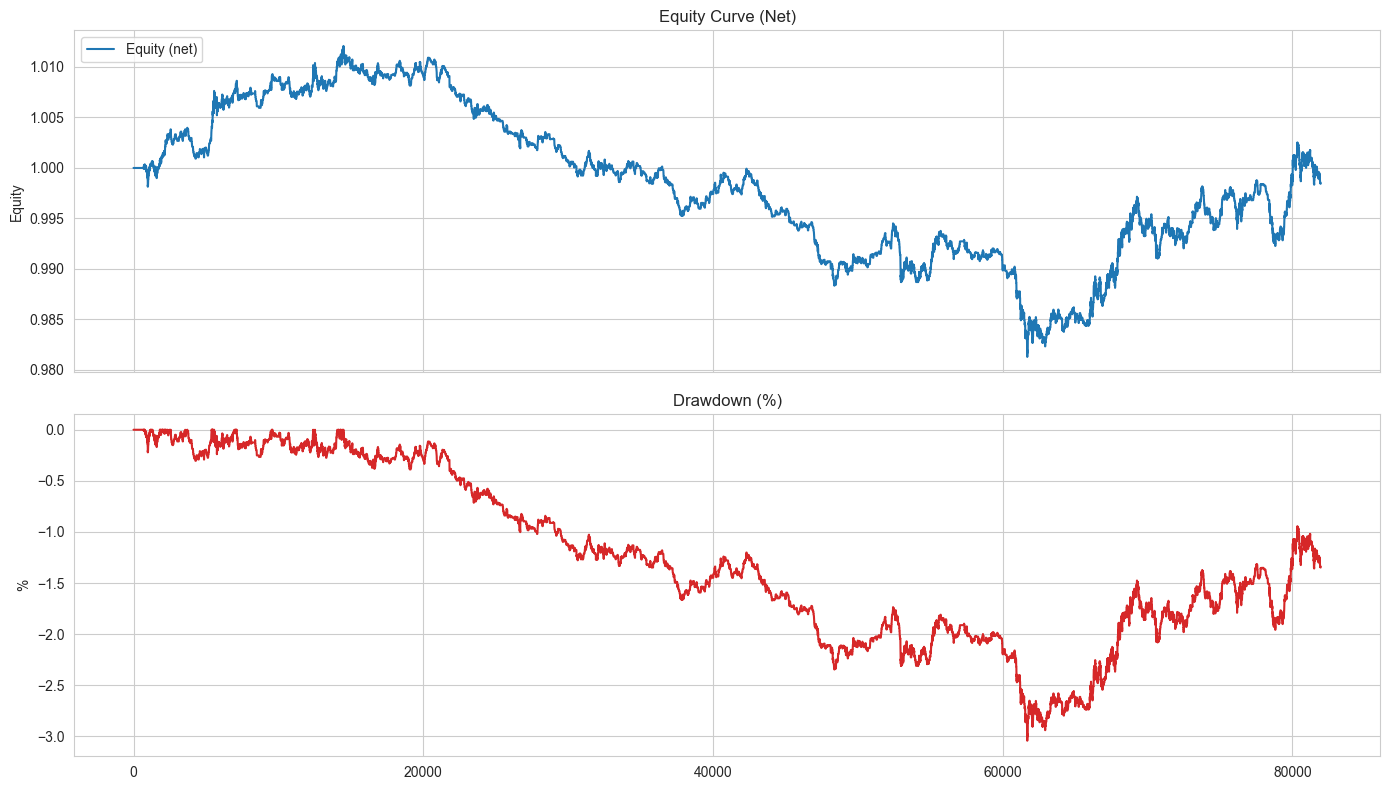

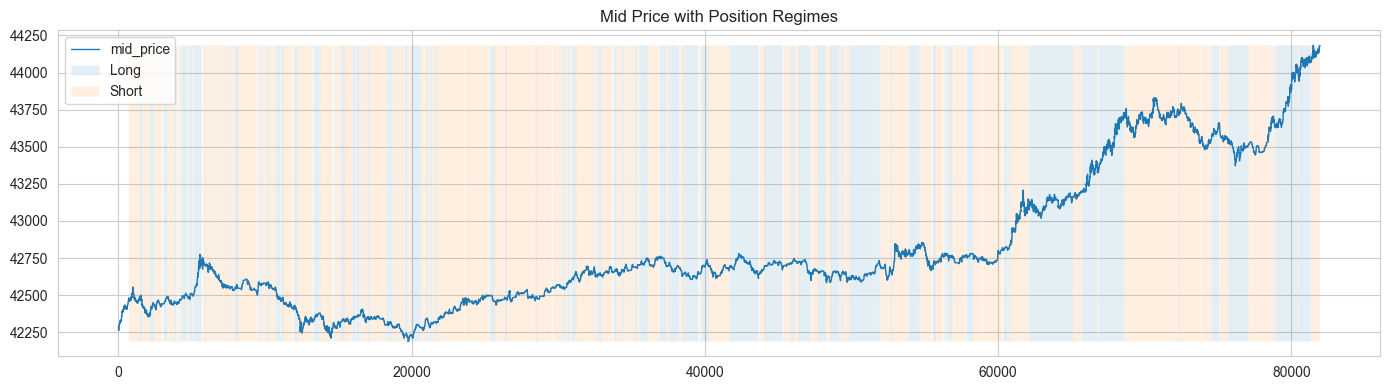

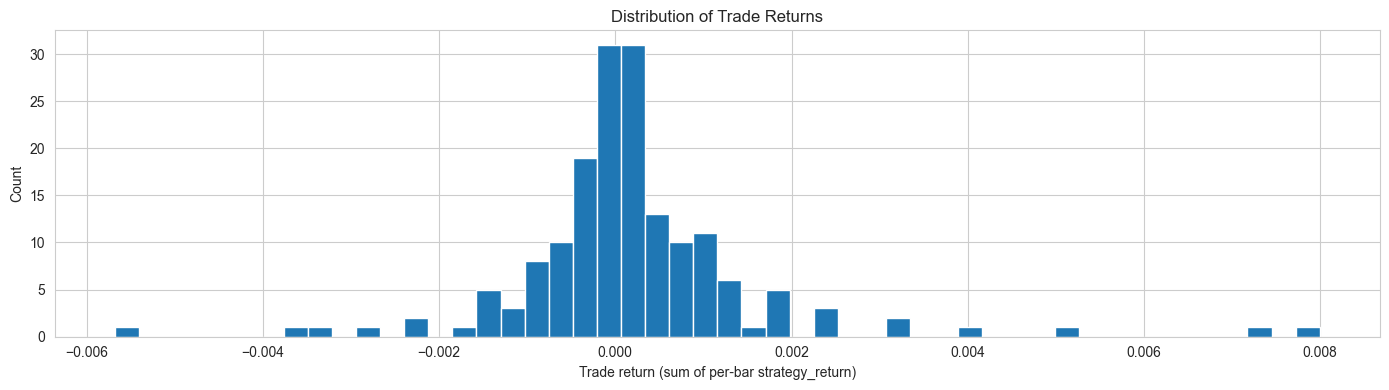

In [26]:
# Backtest report plots (equity/drawdown, regimes, trade distribution)

results, bt = backtest_strategy_vectorized(
    df,
    threshold=0.93,
    stop_loss=2.0,
    take_profit=5.0,
    return_df=True,
)

fig, ax = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
ax[0].plot(bt['equity'], label='Equity (net)')
ax[0].set_title('Equity Curve (Net)')
ax[0].set_ylabel('Equity')
ax[0].legend(loc='upper left')

ax[1].plot(bt['drawdown'] * 100, color='tab:red')
ax[1].set_title('Drawdown (%)')
ax[1].set_ylabel('%')
plt.tight_layout()
plt.show()

# Price with position regimes
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(bt['mid_price'], label='mid_price', linewidth=1)

pos = bt['position'].shift(1).fillna(0)
ymin, ymax = float(bt['mid_price'].min()), float(bt['mid_price'].max())
ax.fill_between(bt.index, ymin, ymax, where=(pos > 0), alpha=0.12, label='Long')
ax.fill_between(bt.index, ymin, ymax, where=(pos < 0), alpha=0.12, label='Short')

ax.set_title('Mid Price with Position Regimes')
ax.legend(loc='upper left')
plt.tight_layout()
plt.show()

# Trade return distribution
pos_now = bt['position'].fillna(0)
trade_groups = (pos_now != pos_now.shift(1).fillna(0)).cumsum()
trade_returns = bt.groupby(trade_groups)['strategy_return'].sum()
active = bt.groupby(trade_groups)['position'].first() != 0
real_trade_returns = trade_returns[active]

plt.figure(figsize=(14, 4))
plt.hist(real_trade_returns, bins=50)
plt.title('Distribution of Trade Returns')
plt.xlabel('Trade return (sum of per-bar strategy_return)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

## Optimization Approaches (Graph-Based Discussion)

### PuLP / Recursive Grid (Exact Baseline)

The **recursive grid search** was used as the “exact” baseline for performance benchmarking. The method was treated as exact **only within the discretized grid points** that were evaluated. A large set of \((T, L, P)\) combinations was tested on a grid, after which a **Branch & Zoom** procedure was applied: search bounds were repeatedly narrowed around the best grid point and the grid was re-evaluated.

From the **iteration outputs** (e.g., “Current Best Sharpe … at \(T=\) …”), large changes in the best Sharpe across zoom rounds were observed. This was interpreted as evidence that the objective surface is **irregular and non-smooth**, where high-performing regions may be narrow. As a result, it was noted that performance can be sensitive to **initial grid resolution** and step sizes, and that the true optimum can be missed if it lies **between grid points** unless a much denser grid is used (which increases computation).

---

### PyGAD (Metaheuristic Exploration)

To support exploration of the **continuous** parameter space, a **Genetic Algorithm (PyGAD)** was applied. Parameters were encoded as real-valued genes \([T, L, P]\) representing threshold, stop-loss, and take-profit. Solutions were evolved using **tournament selection**, **crossover**, and **mutation**, allowing intermediate values to be explored beyond fixed grid steps.

In the **convergence results** (50 generations), progressive improvement in the best fitness across generations was reported, consistent with evolutionary refinement. In the **Sharpe Ratio comparison plot**, final Sharpe outcomes for the recursive method and GA were compared directly, providing visual evidence of which approach achieved the higher risk-adjusted performance on the dataset used.

---

### Constraint Handling and Graph-Based Validation

Because high Sharpe values can occur alongside unrealistic trading behavior, constraints were incorporated through a **penalty-based fitness formulation** in the GA. Penalties were applied when:

- **Maximum drawdown exceeded 10%**
- **Transaction costs became excessive relative to gross profit**
- **Trade count fell below a minimum threshold** (to reduce “Sharpe illusion” from small samples)

Validation was supported by the plotted and tabulated outputs:

- In the **Max Drawdown bar chart**, a **10% constraint line** was included, enabling feasibility to be checked visually.
- In the **comparison table**, Sharpe, drawdown, transaction costs, gross profit, number of trades, and win rate were reported so the final choice could be justified using multiple criteria rather than Sharpe alone.

---

## Section 5: Exact Optimization — Branch & Bound with Recursive Zoom

### Why Branch & Bound?

The assignment requires one **exact method** (ILP, Branch & Bound, or Dynamic Programming). We implement a **Branch & Bound (B&B)** approach adapted for black-box objective functions.

### How Our B&B Works

Standard B&B decomposes a problem into subproblems (branching), computes bounds on each subproblem (bounding), and prunes subproblems that cannot improve on the best known solution (pruning). Our adaptation:

| B&B Component | Implementation |
|---|---|
| **Branching** | The 3D parameter space $(T, L, P)$ is recursively subdivided into grid cells. Each iteration creates $k^3$ subregions. |
| **Bounding** | Each subregion is evaluated by backtesting its center point. The best Sharpe found so far serves as the **incumbent lower bound**. |
| **Pruning** | After each iteration, only the region around the best-performing point survives — all other subregions are pruned. The surviving region is subdivided further (zoom). |
| **Feasibility** | Constraint violations (drawdown, cost ratio, min trades) are penalized via a soft-penalty scoring function, allowing the search to orient toward feasible regions. |
| **Termination** | After a fixed number of zoom iterations, the best feasible solution found across all evaluated points is returned as the optimum *within grid resolution*. |

### Optimality Guarantee

Within the discretized grid, this method is **exact**: every grid point is evaluated, and the global optimum *among evaluated points* is guaranteed. The zoom refinement narrows the search to high-performing subregions, achieving finer resolution where it matters most.

> **Limitation**: The true continuous optimum may lie between grid points. This is why we also apply the GA, which operates in continuous space.

EXACT OPTIMIZATION: RECURSIVE GRID SEARCH (ZOOM + CONSTRAINTS)

--- Iteration 1: evaluating 216 grid points ---
Iter best (feasible): Sharpe=-15.2402 at T=0.9500, L=0.100%, P=3.400%

--- Iteration 2: evaluating 216 grid points ---
Iter best (feasible): Sharpe=21.8455 at T=0.9950, L=0.345%, P=1.485%

--- Iteration 3: evaluating 216 grid points ---
Iter best (feasible): Sharpe=9.0043 at T=0.9725, L=0.100%, P=1.347%

✓ Recursive Exact Optimization completed in 39.19s


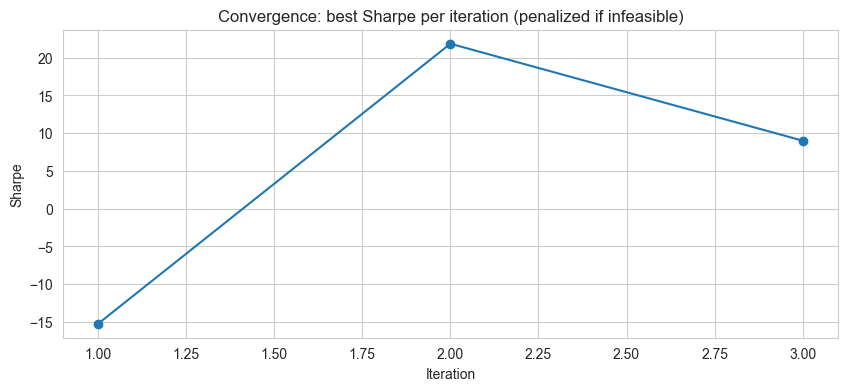

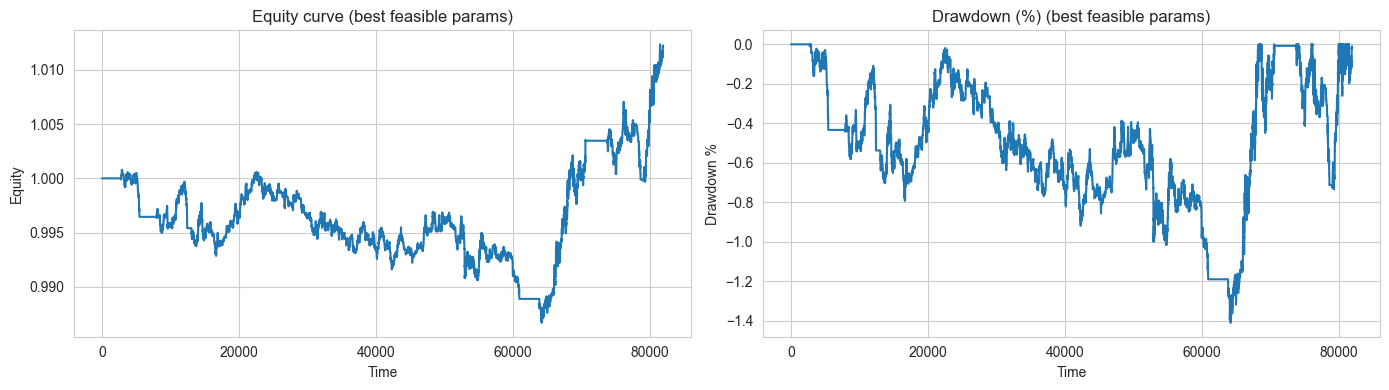


   OPTIMAL PARAMETERS (FEASIBLE)
Threshold (T):     0.9950
Stop-Loss (L):     0.35%
Take-Profit (P):   1.49%
----------------------------------------
   PERFORMANCE SUMMARY
----------------------------------------
Sharpe Ratio:      21.8455
Net Profit:        1.23%
Max Drawdown:      1.41%
Win Rate:          50.00%
Total Trades:      34


In [27]:
def optimize_exact_recursive(
    df,
    iterations=3,
    points_per_dim=6,
    width_reduction=0.5,
    transaction_cost_pct=0.0001,
    constraints=None,
    plot=True,
    timestamp_col='timestamp',
):
    """Recursive grid search (zoom-in) with feasibility constraints + diagnostics.

    Improvements vs the original:
    - Enforces feasibility constraints (min trades, max drawdown, cost ratio)
    - Stores *all* evaluations in a DataFrame (auditability + plotting)
    - Returns iteration history (convergence)
    - Plots convergence + equity/drawdown of best feasible solution
    """

    default_constraints = {
        # NOTE: in HFT-style data it’s common to have fewer distinct "trades" than expected.
        # Start with lighter defaults and tighten once you see stable behavior.
        'min_trades': 20,
        'max_drawdown_pct': 10.0,
        # transaction_costs as % of |gross_profit| (robust when gross_profit is small/negative)
        'max_cost_pct_of_gross_profit': 50.0,
    }
    if constraints is None:
        constraints = default_constraints
    else:
        constraints = {**default_constraints, **constraints}

    print("=" * 70)
    print("EXACT OPTIMIZATION: RECURSIVE GRID SEARCH (ZOOM + CONSTRAINTS)")
    print("=" * 70)

    start_time = time.time()

    bounds = {
        'T': (0.05, 0.95),
        'L': (0.1, 5.0),
        'P': (0.5, 15.0),
    }

    best_overall_res = None
    best_overall_score = -np.inf

    history = []
    grid_records = []

    def feasibility_flags(res):
        """Return (feasible, flags_dict) for diagnostics."""
        flags = {
            'min_trades_ok': int(res['num_trades']) >= int(constraints['min_trades']),
            'max_dd_ok': float(res['max_drawdown']) <= float(constraints['max_drawdown_pct']),
            'cost_ok': True,
        }

        gp = float(res.get('gross_profit', 0.0))
        tc = float(res.get('transaction_costs', 0.0))
        denom = max(abs(gp), 1e-9)
        cost_ratio = (tc / denom) * 100.0
        flags['cost_ratio'] = float(cost_ratio)
        flags['cost_ok'] = cost_ratio <= float(constraints['max_cost_pct_of_gross_profit'])

        feasible = bool(flags['min_trades_ok'] and flags['max_dd_ok'] and flags['cost_ok'])
        return feasible, flags

    def score(res, flags, feasible):
        """Soft-penalty scoring; still prefers feasible if any exist."""
        sharpe = float(res['sharpe_ratio'])
        if feasible:
            return sharpe

        # Penalize constraint violations instead of discarding everything.
        penalty = 0.0
        if not flags['min_trades_ok']:
            # scale by how far below min_trades we are
            shortfall = (int(constraints['min_trades']) - int(res['num_trades'])) / max(int(constraints['min_trades']), 1)
            penalty += 5.0 * max(shortfall, 0.0)
        if not flags['max_dd_ok']:
            penalty += 0.5 * max(float(res['max_drawdown']) - float(constraints['max_drawdown_pct']), 0.0)
        if not flags['cost_ok']:
            penalty += 0.05 * max(float(flags['cost_ratio']) - float(constraints['max_cost_pct_of_gross_profit']), 0.0)

        return sharpe - penalty

    for i in range(iterations):
        print(f"\n--- Iteration {i+1}: evaluating {points_per_dim**3} grid points ---")

        thresholds = np.linspace(bounds['T'][0], bounds['T'][1], points_per_dim)
        stop_losses = np.linspace(bounds['L'][0], bounds['L'][1], points_per_dim)
        take_profits = np.linspace(bounds['P'][0], bounds['P'][1], points_per_dim)

        iteration_best_params = None
        iteration_best_score = -np.inf
        iteration_best_res = None

        for t in thresholds:
            for l in stop_losses:
                for p in take_profits:
                    res = backtest_strategy_vectorized(
                        df,
                        threshold=float(t),
                        stop_loss=float(l),
                        take_profit=float(p),
                        transaction_cost_pct=transaction_cost_pct,
                        timestamp_col=timestamp_col,
                    )

                    feasible, flags = feasibility_flags(res)
                    s = score(res, flags, feasible)

                    grid_records.append(
                        {
                            'iter': i + 1,
                            'threshold': float(res['threshold']),
                            'stop_loss': float(res['stop_loss']),
                            'take_profit': float(res['take_profit']),
                            'sharpe_ratio': float(res['sharpe_ratio']),
                            'net_profit': float(res['net_profit']),
                            'max_drawdown': float(res['max_drawdown']),
                            'num_trades': int(res['num_trades']),
                            'gross_profit': float(res.get('gross_profit', np.nan)),
                            'transaction_costs': float(res.get('transaction_costs', np.nan)),
                            'cost_ratio': float(flags['cost_ratio']),
                            'min_trades_ok': bool(flags['min_trades_ok']),
                            'max_dd_ok': bool(flags['max_dd_ok']),
                            'cost_ok': bool(flags['cost_ok']),
                            'feasible': bool(feasible),
                            'score': float(s) if np.isfinite(s) else -np.inf,
                        }
                    )

                    if s > iteration_best_score:
                        iteration_best_score = s
                        iteration_best_params = (float(t), float(l), float(p))
                        iteration_best_res = res

                    if s > best_overall_score:
                        best_overall_score = s
                        best_overall_res = res

        if iteration_best_params is None:
            print("No parameters evaluated (unexpected).")
            break

        t_best, l_best, p_best = iteration_best_params

        history.append(
            {
                'iter': i + 1,
                'best_sharpe': float(iteration_best_res['sharpe_ratio']),
                't_best': t_best,
                'l_best': l_best,
                'p_best': p_best,
                'T_low': bounds['T'][0],
                'T_high': bounds['T'][1],
                'L_low': bounds['L'][0],
                'L_high': bounds['L'][1],
                'P_low': bounds['P'][0],
                'P_high': bounds['P'][1],
            }
        )

        # Zoom bounds around the best feasible point
        for key, val, floor_val in [
            ('T', t_best, 0.01),
            ('L', l_best, 0.1),
            ('P', p_best, 0.1),
        ]:
            current_range = (bounds[key][1] - bounds[key][0]) * float(width_reduction)
            new_low = max(float(floor_val), float(val) - current_range / 2)
            new_high = float(val) + current_range / 2
            bounds[key] = (float(new_low), float(new_high))

        print(
            f"Iter best (feasible): Sharpe={iteration_best_res['sharpe_ratio']:.4f} "
            f"at T={t_best:.4f}, L={l_best:.3f}%, P={p_best:.3f}%"
        )

    total_time = time.time() - start_time
    print(f"\n✓ Recursive Exact Optimization completed in {total_time:.2f}s")

    history_df = pd.DataFrame(history)
    grid_df = pd.DataFrame(grid_records)

    # Diagnostics when nothing is feasible
    feasible_count = int(grid_df['feasible'].sum()) if len(grid_df) else 0
    if feasible_count == 0 and len(grid_df):
        print("\n⚠ No fully-feasible parameters under current constraints.")
        print("Infeasibility breakdown (across all evaluated points):")
        print(f"- min_trades_ok: {int(grid_df['min_trades_ok'].sum())}/{len(grid_df)}")
        print(f"- max_dd_ok:     {int(grid_df['max_dd_ok'].sum())}/{len(grid_df)}")
        print(f"- cost_ok:       {int(grid_df['cost_ok'].sum())}/{len(grid_df)}")

        # Pick best penalized as fallback so you still get a candidate to inspect
        best_idx = int(grid_df['score'].idxmax())
        cand = grid_df.loc[best_idx]
        best_overall_res = backtest_strategy_vectorized(
            df,
            threshold=float(cand['threshold']),
            stop_loss=float(cand['stop_loss']),
            take_profit=float(cand['take_profit']),
            transaction_cost_pct=transaction_cost_pct,
            timestamp_col=timestamp_col,
        )
        best_overall_res['feasible'] = False
    elif best_overall_res is not None:
        best_overall_res['feasible'] = True

    if plot and len(history_df):
        plt.figure(figsize=(10, 4))
        plt.plot(history_df['iter'], history_df['best_sharpe'], marker='o')
        plt.title('Convergence: best Sharpe per iteration (penalized if infeasible)')
        plt.xlabel('Iteration')
        plt.ylabel('Sharpe')
        plt.grid(True)
        plt.show()

    if plot and best_overall_res is not None:
        _, best_bt_df = backtest_strategy_vectorized(
            df,
            threshold=best_overall_res['threshold'],
            stop_loss=best_overall_res['stop_loss'],
            take_profit=best_overall_res['take_profit'],
            transaction_cost_pct=transaction_cost_pct,
            timestamp_col=timestamp_col,
            return_df=True,
        )

        fig, ax = plt.subplots(1, 2, figsize=(14, 4))
        ax[0].plot(best_bt_df['equity'])
        ax[0].set_title('Equity curve (best feasible params)')
        ax[0].set_xlabel('Time')
        ax[0].set_ylabel('Equity')

        ax[1].plot(best_bt_df['drawdown'] * 100)
        ax[1].set_title('Drawdown (%) (best feasible params)')
        ax[1].set_xlabel('Time')
        ax[1].set_ylabel('Drawdown %')
        plt.tight_layout()
        plt.show()

    return {
        'results': best_overall_res,
        'runtime': float(total_time),
        'history': history_df,
        'grid': grid_df,
        'constraints': constraints,
    }


recursive_results = optimize_exact_recursive(df, iterations=3, points_per_dim=6, plot=True)

print("\n" + "=" * 40)
print("   OPTIMAL PARAMETERS (FEASIBLE)")
print("=" * 40)
if recursive_results['results'] is None:
    print("No feasible solution found. Try relaxing constraints.")
else:
    r = recursive_results['results']
    print(f"Threshold (T):     {r['threshold']:.4f}")
    print(f"Stop-Loss (L):     {r['stop_loss']:.2f}%")
    print(f"Take-Profit (P):   {r['take_profit']:.2f}%")
    print("-" * 40)
    print("   PERFORMANCE SUMMARY")
    print("-" * 40)
    print(f"Sharpe Ratio:      {r['sharpe_ratio']:.4f}")
    print(f"Net Profit:        {r['net_profit']:.2f}%")
    print(f"Max Drawdown:      {r['max_drawdown']:.2f}%")
    print(f"Win Rate:          {r['win_rate']:.2f}%")
    print(f"Total Trades:      {r['num_trades']}")
    print("=" * 40)

## Section 6: Metaheuristic Optimization Using Genetic Algorithm (PyGAD)

In [28]:
def optimize_with_ga(df, num_generations=50):
    """
    Metaheuristic optimization using Genetic Algorithm (PyGAD).
    
    Gene encoding:
    - Gene 0: Threshold T  [0.01, 1.0]
    - Gene 1: Stop-loss L  [0.1, 10.0] %
    - Gene 2: Take-profit P [0.1, 20.0] %
    
    Fitness function: Sharpe Ratio with constraint penalties
    """
    
    print("\n" + "=" * 60)
    print("STARTING METAHEURISTIC OPTIMIZATION WITH GENETIC ALGORITHM")
    print("=" * 60)
    
    # Storage for convergence tracking
    ga_instance_storage = {'ga': None}
    generation_scores = []
    
    def fitness_function(ga_instance, solution, solution_idx):
        """
        Fitness function: Sharpe Ratio with constraint penalties.
        """
        threshold = solution[0]
        stop_loss = solution[1]
        take_profit = solution[2]
        
        try:
            result = backtest_strategy_vectorized(df, 
                                     threshold=threshold, 
                                     stop_loss=stop_loss, 
                                     take_profit=take_profit)
            
            sharpe = result['sharpe_ratio']
            max_dd = result['max_drawdown']
            trans_cost = result['transaction_costs']
            gross_profit = result['gross_profit']
            
            # Penalty for constraint violation
            penalty = 0
            
            if max_dd > 10.0:
                penalty += (max_dd - 10.0) * 10
            
            # STRICT FIX: Heavy penalty for negative profit and high fees
            if gross_profit <= 0:
                penalty += 500
            elif trans_cost > gross_profit * 0.2:
                penalty += (trans_cost - gross_profit * 0.2) * 5
                
            # SHARPE ILLUSION FIX: Penalize low trade counts heavily
            if result['num_trades'] < 50:
                penalty += 500
            
            fitness = sharpe - penalty
            
        except:
            fitness = -1000  # Very bad fitness for invalid solutions
        
        return fitness
    
    start_time = time.time()
    
    # Reset seeds right before GA run for reproducibility
    random.seed(SEED)
    np.random.seed(SEED)
    
    # FIX: Custom callback MUST be defined before passing it to PyGAD
    def on_generation_complete(ga_instance):
        gen_best = ga_instance.best_solution()[1]  
        generation_scores.append(gen_best)

    # Create GA instance
    ga_instance = pygad.GA(
        num_generations=num_generations,
        num_parents_mating=4,
        fitness_func=fitness_function,
        on_generation=on_generation_complete,
        sol_per_pop=20,
        num_genes=3,
        gene_space=[
            {"low": 0.01, "high": 1.0},
            {"low": 0.1,  "high": 10.0},
            {"low": 0.1,  "high": 20.0},
        ],
        parent_selection_type="tournament",
        K_tournament=3,
        mutation_type="random",
        mutation_percent_genes=25,
        crossover_type="single_point",
        stop_criteria=["saturate_25"],
        random_seed=SEED
    )
    
    # Run GA
    ga_instance.run()
    
    elapsed_time = time.time() - start_time
    
    # Get best solution
    best_solution, best_fitness, _ = ga_instance.best_solution()
    
    threshold_ga = best_solution[0]
    stop_loss_ga = best_solution[1]
    take_profit_ga = best_solution[2]
    
    # Evaluate best solution
    result_ga = backtest_strategy_vectorized(df, 
                                            threshold=threshold_ga, 
                                            stop_loss=stop_loss_ga, 
                                            take_profit=take_profit_ga)
    
    print(f"\n✓ Optimization completed in {elapsed_time:.2f} seconds")
    print(f"✓ Generations evolved: {len(generation_scores)}")
    print(f"\nOptimal Parameters (GA):")
    print(f"  Threshold (T): {threshold_ga:.3f}")
    print(f"  Stop-Loss (L): {stop_loss_ga:.2f}%")
    print(f"  Take-Profit (P): {take_profit_ga:.2f}%")
    print(f"\nPerformance Metrics:")
    print(f"  Sharpe Ratio: {result_ga['sharpe_ratio']:.4f}")
    print(f"  Max Drawdown: {result_ga['max_drawdown']:.2f}%")
    print(f"  Transaction Costs: {result_ga['transaction_costs']:.2f}%")
    print(f"  Gross Profit: {result_ga['gross_profit']:.2f}%")
    
    return {
        'parameters': {
            'threshold': threshold_ga,
            'stop_loss': stop_loss_ga,
            'take_profit': take_profit_ga
        },
        'results': result_ga,
        'runtime': elapsed_time,
        'generation_scores': generation_scores,
        'ga_instance': ga_instance
    }

# Run Genetic Algorithm optimization
ga_result = optimize_with_ga(df, num_generations=50)
ga_results = ga_result['results']
ga_generations = ga_result['generation_scores']


STARTING METAHEURISTIC OPTIMIZATION WITH GENETIC ALGORITHM

✓ Optimization completed in 102.14 seconds
✓ Generations evolved: 50

Optimal Parameters (GA):
  Threshold (T): 0.986
  Stop-Loss (L): 0.28%
  Take-Profit (P): 5.07%

Performance Metrics:
  Sharpe Ratio: 25.7514
  Max Drawdown: 1.92%
  Transaction Costs: 1.09%
  Gross Profit: 2.51%


### GA Diagnostics: Convergence, Equity Curve, Drawdown & Trade Returns

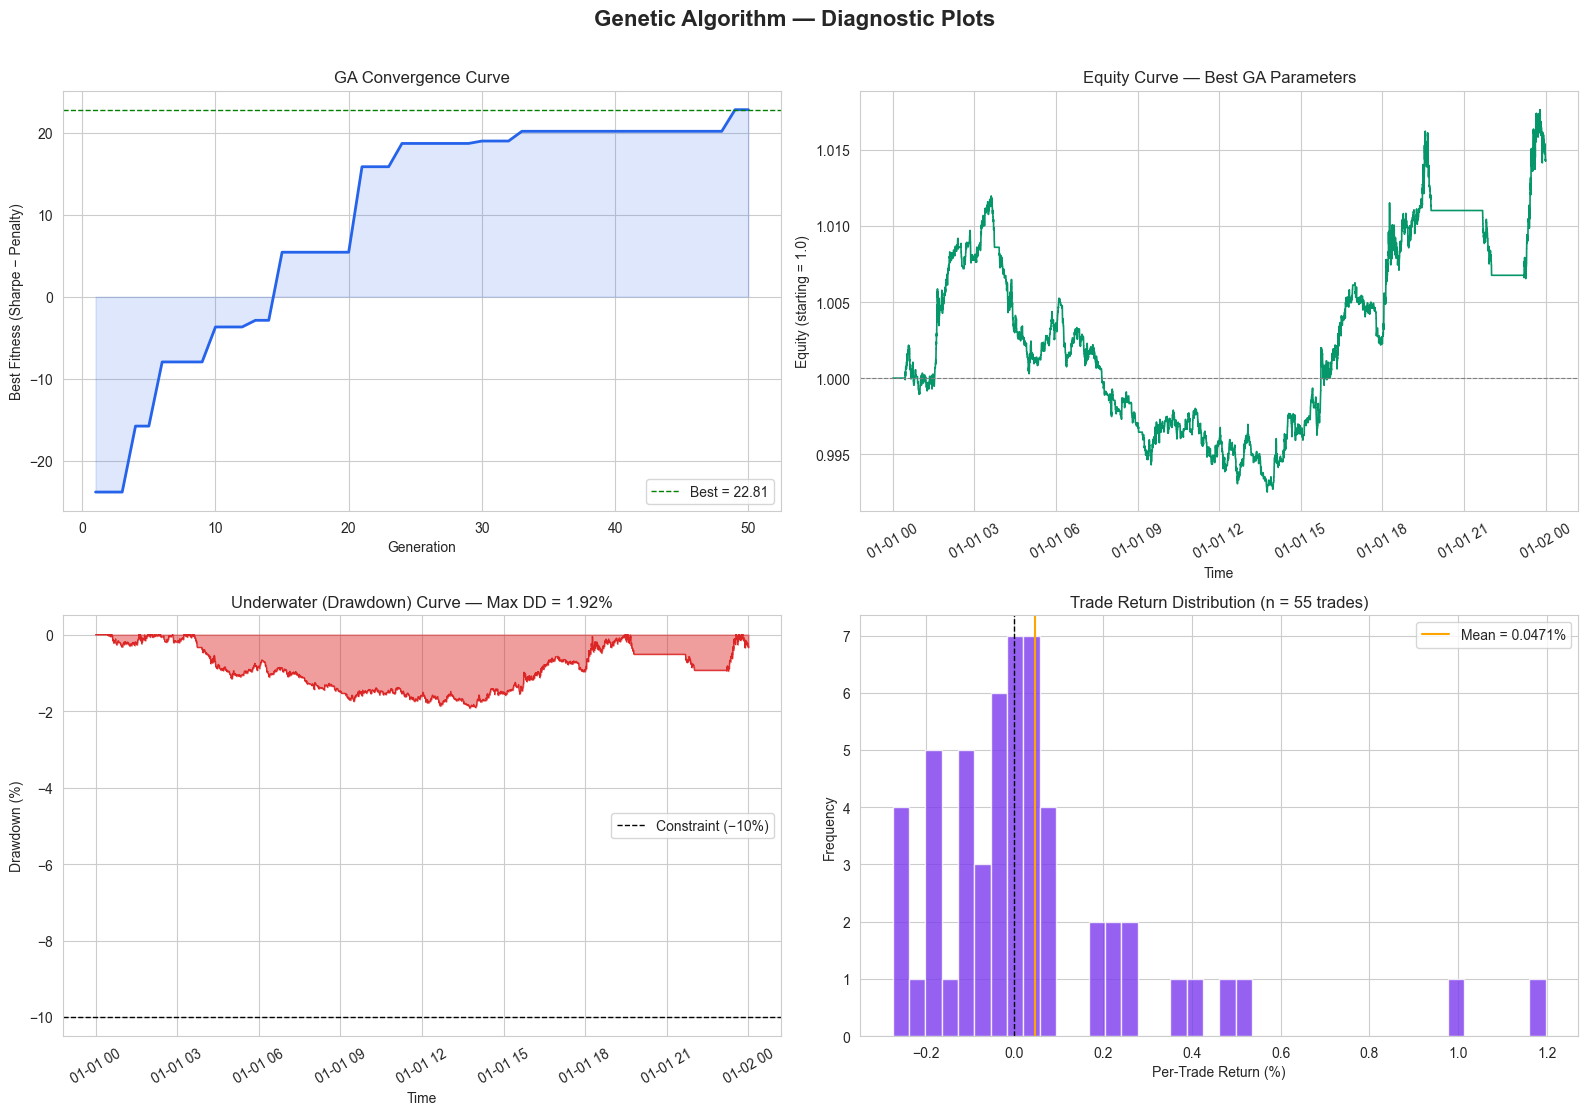


GA Best Parameters → T=0.986, L=0.28%, P=5.07%
Sharpe=25.7514  |  Net Profit=1.42%  |  Max DD=1.92%  |  Trades=55  |  Win Rate=45.5%


In [29]:
# --- Re-run the best GA solution with return_df=True to get the full backtest DataFrame ---
ga_params = ga_result['parameters']
ga_bt_results, ga_bt_df = backtest_strategy_vectorized(
    df,
    threshold=ga_params['threshold'],
    stop_loss=ga_params['stop_loss'],
    take_profit=ga_params['take_profit'],
    return_df=True,
)

fig, axes = plt.subplots(2, 2, figsize=(16, 11))
fig.suptitle('Genetic Algorithm — Diagnostic Plots', fontsize=16, fontweight='bold', y=1.01)

# ── 1. GA Convergence ──
ax = axes[0, 0]
gens = range(1, len(ga_generations) + 1)
ax.plot(gens, ga_generations, color='#2563eb', linewidth=2)
ax.fill_between(gens, ga_generations, alpha=0.15, color='#2563eb')
ax.set_xlabel('Generation')
ax.set_ylabel('Best Fitness (Sharpe − Penalty)')
ax.set_title('GA Convergence Curve')
ax.axhline(y=max(ga_generations), color='green', linestyle='--', linewidth=1,
           label=f'Best = {max(ga_generations):.2f}')
ax.legend()

# ── 2. Equity Curve ──
ax = axes[0, 1]
ts = ga_bt_df['timestamp'] if 'timestamp' in ga_bt_df.columns else ga_bt_df.index
ax.plot(ts, ga_bt_df['equity'], color='#059669', linewidth=1.2)
ax.set_xlabel('Time')
ax.set_ylabel('Equity (starting = 1.0)')
ax.set_title('Equity Curve — Best GA Parameters')
ax.axhline(y=1.0, color='grey', linestyle='--', linewidth=0.8)
ax.tick_params(axis='x', rotation=30)

# ── 3. Drawdown ──
ax = axes[1, 0]
ax.fill_between(ts, ga_bt_df['drawdown'] * 100, color='#dc2626', alpha=0.45)
ax.plot(ts, ga_bt_df['drawdown'] * 100, color='#dc2626', linewidth=0.8)
ax.set_xlabel('Time')
ax.set_ylabel('Drawdown (%)')
ax.set_title(f'Underwater (Drawdown) Curve — Max DD = {ga_bt_results["max_drawdown"]:.2f}%')
ax.axhline(y=-10, color='black', linestyle='--', linewidth=1, label='Constraint (−10%)')
ax.legend()
ax.tick_params(axis='x', rotation=30)

# ── 4. Per-Trade Return Distribution ──
ax = axes[1, 1]
pos = ga_bt_df['position'].fillna(0)
prev = pos.shift(1).fillna(0)
trade_groups = (pos != prev).cumsum()
trade_returns = ga_bt_df.groupby(trade_groups)['strategy_return'].sum()
is_active = ga_bt_df.groupby(trade_groups)['position'].first() != 0
real_trade_returns = trade_returns[is_active] * 100

ax.hist(real_trade_returns, bins=40, color='#7c3aed', edgecolor='white', alpha=0.8)
ax.axvline(x=0, color='black', linestyle='--', linewidth=1)
mean_tr = real_trade_returns.mean()
ax.axvline(x=mean_tr, color='orange', linestyle='-', linewidth=1.5,
           label=f'Mean = {mean_tr:.4f}%')
ax.set_xlabel('Per-Trade Return (%)')
ax.set_ylabel('Frequency')
ax.set_title(f'Trade Return Distribution (n = {len(real_trade_returns)} trades)')
ax.legend()

plt.tight_layout()
plt.show()

print(f"\nGA Best Parameters → T={ga_params['threshold']:.3f}, "
      f"L={ga_params['stop_loss']:.2f}%, P={ga_params['take_profit']:.2f}%")
print(f"Sharpe={ga_bt_results['sharpe_ratio']:.4f}  |  Net Profit={ga_bt_results['net_profit']:.2f}%  "
      f"|  Max DD={ga_bt_results['max_drawdown']:.2f}%  |  Trades={ga_bt_results['num_trades']}  "
      f"|  Win Rate={ga_bt_results['win_rate']:.1f}%")

## Section 7: Compare and Visualize Results

In [30]:
pulp_perf = recursive_results['results']
ga_perf = ga_result['results']


comparison_data = {
    'Metric': [
        'Threshold (T)',
        'Stop-Loss (L) %',
        'Take-Profit (P) %',
        'Sharpe Ratio',
        'Max Drawdown %',
        'Transaction Costs %',
        'Gross Profit %',
        'Number of Trades',
        'Win Rate %'
    ],
    'Recursive (Exact)': [
        f"{pulp_perf['threshold']:.3f}",
        f"{pulp_perf['stop_loss']:.2f}",
        f"{pulp_perf['take_profit']:.2f}",
        f"{pulp_perf['sharpe_ratio']:.4f}",
        f"{pulp_perf['max_drawdown']:.2f}",
        f"{pulp_perf['transaction_costs']:.2f}",
        f"{pulp_perf['gross_profit']:.2f}",
        f"{pulp_perf['num_trades']}",
        f"{pulp_perf['win_rate']:.2f}"
    ],
    'PyGAD (GA)': [
        f"{ga_perf['threshold']:.3f}",
        f"{ga_perf['stop_loss']:.2f}",
        f"{ga_perf['take_profit']:.2f}",
        f"{ga_perf['sharpe_ratio']:.4f}",
        f"{ga_perf['max_drawdown']:.2f}",
        f"{ga_perf['transaction_costs']:.2f}",
        f"{ga_perf['gross_profit']:.2f}",
        f"{ga_perf['num_trades']}",
        f"{ga_perf['win_rate']:.2f}"
    ]
}

comparison_df = pd.DataFrame(comparison_data)

print("\n" + "=" * 80)
print("OPTIMIZATION RESULTS COMPARISON")
print("=" * 80)
print(comparison_df.to_string(index=False))
print("=" * 80)

print(f"\nRuntime Comparison:")
print(f"  Exact (Recursive): {recursive_results['runtime']:.2f} seconds")
print(f"  PyGAD (GA):        {ga_result['runtime']:.2f} seconds")
speedup = recursive_results['runtime'] / ga_result['runtime'] if ga_result['runtime'] > 0 else float('inf')
print(f"  Speed ratio:       Exact is {speedup:.1f}x {'slower' if speedup > 1 else 'faster'} than GA")

print(f"\nConstraint Check:")
for name, perf in [("Exact", pulp_perf), ("GA", ga_perf)]:
    dd_ok = perf['max_drawdown'] <= 10.0
    trades_ok = perf['num_trades'] >= 50
    gp = perf['gross_profit']
    cost_ok = perf['transaction_costs'] <= gp * 0.2 if gp > 0 else False
    status = "PASS" if (dd_ok and trades_ok and cost_ok) else "FAIL"
    print(f"  {name:6s}: DD<10%={'Y' if dd_ok else 'N'}  Trades>=50={'Y' if trades_ok else 'N'}  CostRatio={'Y' if cost_ok else 'N'}  -> {status}")


OPTIMIZATION RESULTS COMPARISON
             Metric Recursive (Exact) PyGAD (GA)
      Threshold (T)             0.995      0.986
    Stop-Loss (L) %              0.35       0.28
  Take-Profit (P) %              1.49       5.07
       Sharpe Ratio           21.8455    25.7514
     Max Drawdown %              1.41       1.92
Transaction Costs %              0.67       1.09
     Gross Profit %              1.90       2.51
   Number of Trades                34         55
         Win Rate %             50.00      45.45

Runtime Comparison:
  Exact (Recursive): 39.19 seconds
  PyGAD (GA):        102.14 seconds
  Speed ratio:       Exact is 0.4x faster than GA

Constraint Check:
  Exact : DD<10%=Y  Trades>=50=N  CostRatio=N  -> FAIL
  GA    : DD<10%=Y  Trades>=50=Y  CostRatio=N  -> FAIL


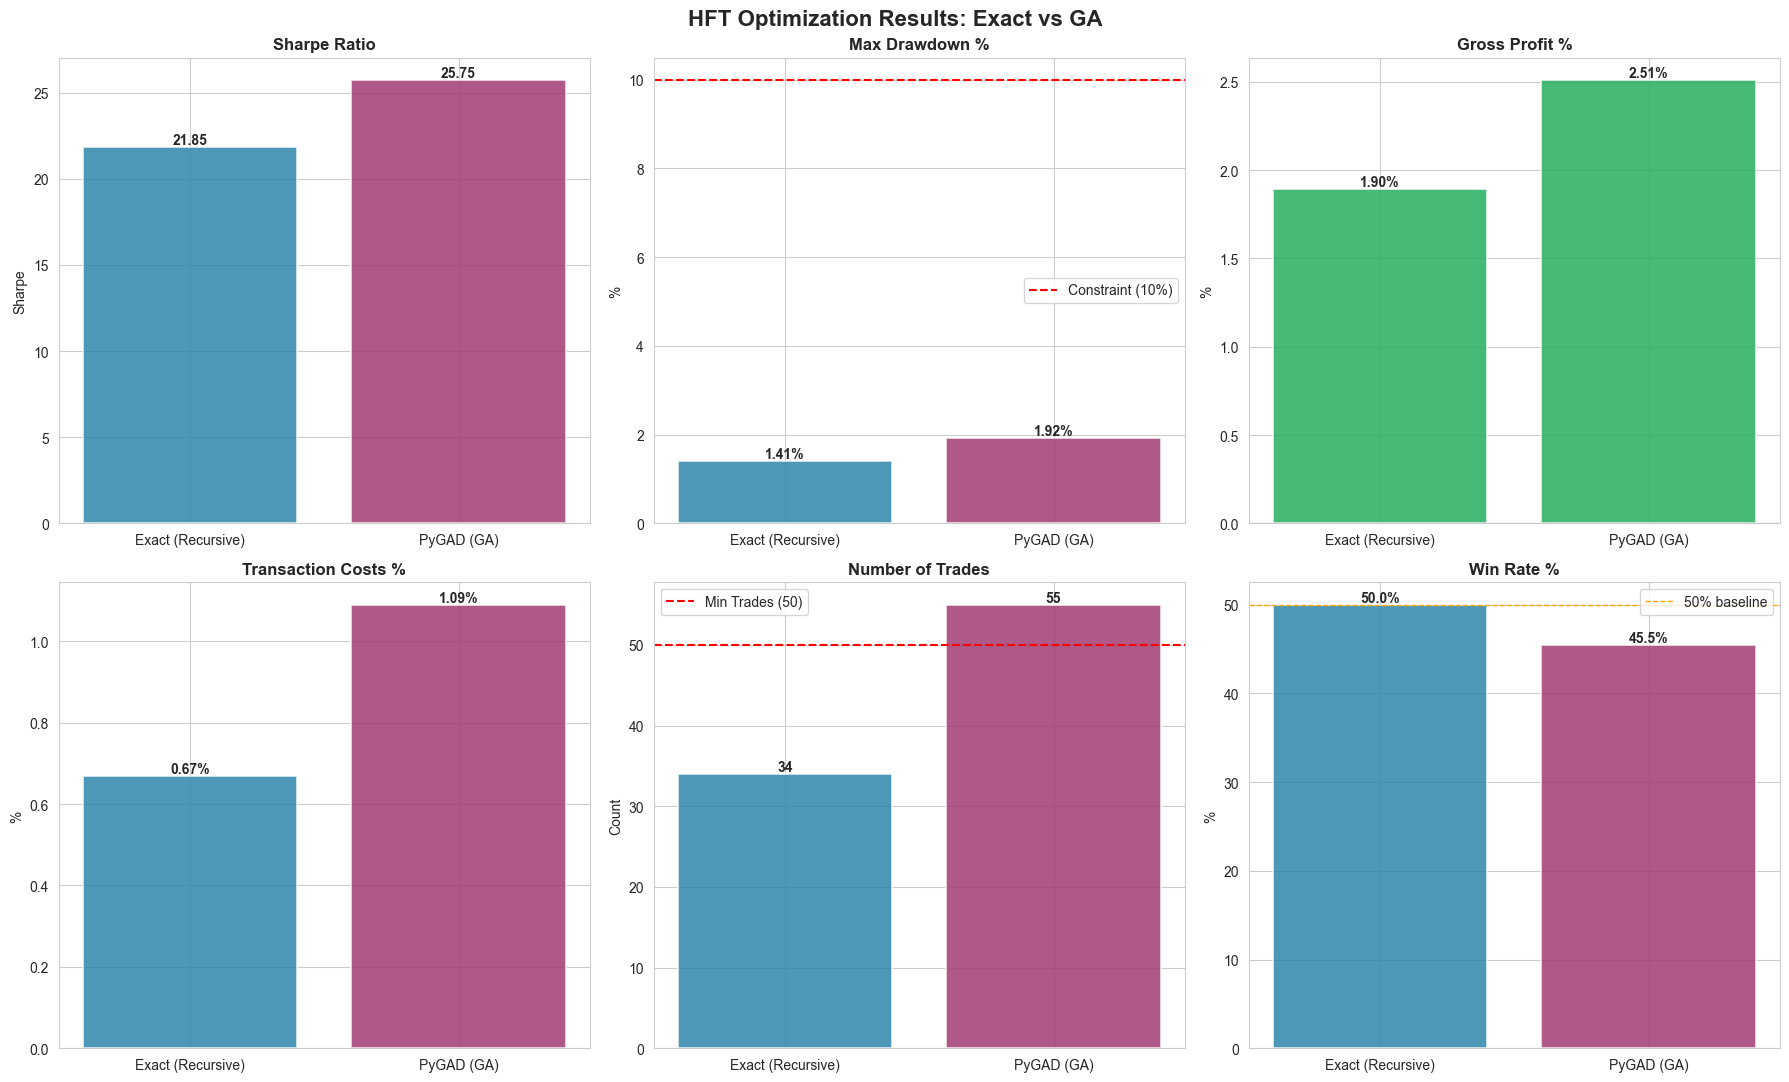


ANALYSIS SUMMARY

🏆 PyGAD (Genetic Algorithm) achieved HIGHER Sharpe Ratio
   Difference: 3.9059

⏱️  Execution Time:
   PuLP was 0.38x slower than PyGAD

📊 Convergence:
   PyGAD evolved over 50 generations
   Final improvement from generation 1: 195.71%



In [31]:
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle('HFT Optimization Results: Exact vs GA', fontsize=16, fontweight='bold')

methods = ['Exact (Recursive)', 'PyGAD (GA)']
colors = ['#2E86AB', '#A23B72']

# 1 — Sharpe Ratio
ax = axes[0, 0]
sharpe_vals = [pulp_perf['sharpe_ratio'], ga_perf['sharpe_ratio']]
bars = ax.bar(methods, sharpe_vals, color=colors, alpha=0.85, edgecolor='white', linewidth=1.2)
for b, v in zip(bars, sharpe_vals):
    ax.text(b.get_x() + b.get_width()/2, b.get_height(), f'{v:.2f}',
            ha='center', va='bottom', fontweight='bold', fontsize=10)
ax.set_title('Sharpe Ratio', fontweight='bold')
ax.set_ylabel('Sharpe')

# 2 — Max Drawdown
ax = axes[0, 1]
dd_vals = [pulp_perf['max_drawdown'], ga_perf['max_drawdown']]
bars = ax.bar(methods, dd_vals, color=colors, alpha=0.85, edgecolor='white', linewidth=1.2)
for b, v in zip(bars, dd_vals):
    ax.text(b.get_x() + b.get_width()/2, b.get_height(), f'{v:.2f}%',
            ha='center', va='bottom', fontweight='bold', fontsize=10)
ax.axhline(y=10.0, color='red', linestyle='--', linewidth=1.5, label='Constraint (10%)')
ax.set_title('Max Drawdown %', fontweight='bold')
ax.set_ylabel('%')
ax.legend()

# 3 — Gross Profit
ax = axes[0, 2]
gp_vals = [pulp_perf['gross_profit'], ga_perf['gross_profit']]
bar_colors = ['#27ae60' if v >= 0 else '#e74c3c' for v in gp_vals]
bars = ax.bar(methods, gp_vals, color=bar_colors, alpha=0.85, edgecolor='white', linewidth=1.2)
for b, v in zip(bars, gp_vals):
    offset = b.get_height() if v >= 0 else b.get_height() - 0.3
    ax.text(b.get_x() + b.get_width()/2, offset, f'{v:.2f}%',
            ha='center', va='bottom', fontweight='bold', fontsize=10)
ax.axhline(y=0, color='grey', linestyle='-', linewidth=0.8)
ax.set_title('Gross Profit %', fontweight='bold')
ax.set_ylabel('%')

# 4 — Transaction Costs
ax = axes[1, 0]
tc_vals = [pulp_perf['transaction_costs'], ga_perf['transaction_costs']]
bars = ax.bar(methods, tc_vals, color=colors, alpha=0.85, edgecolor='white', linewidth=1.2)
for b, v in zip(bars, tc_vals):
    ax.text(b.get_x() + b.get_width()/2, b.get_height(), f'{v:.2f}%',
            ha='center', va='bottom', fontweight='bold', fontsize=10)
ax.set_title('Transaction Costs %', fontweight='bold')
ax.set_ylabel('%')

# 5 — Number of Trades
ax = axes[1, 1]
nt_vals = [pulp_perf['num_trades'], ga_perf['num_trades']]
bars = ax.bar(methods, nt_vals, color=colors, alpha=0.85, edgecolor='white', linewidth=1.2)
for b, v in zip(bars, nt_vals):
    ax.text(b.get_x() + b.get_width()/2, b.get_height(), f'{int(v)}',
            ha='center', va='bottom', fontweight='bold', fontsize=10)
ax.axhline(y=50, color='red', linestyle='--', linewidth=1.5, label='Min Trades (50)')
ax.set_title('Number of Trades', fontweight='bold')
ax.set_ylabel('Count')
ax.legend()

# 6 — Win Rate
ax = axes[1, 2]
wr_vals = [pulp_perf['win_rate'], ga_perf['win_rate']]
bars = ax.bar(methods, wr_vals, color=colors, alpha=0.85, edgecolor='white', linewidth=1.2)
for b, v in zip(bars, wr_vals):
    ax.text(b.get_x() + b.get_width()/2, b.get_height(), f'{v:.1f}%',
            ha='center', va='bottom', fontweight='bold', fontsize=10)
ax.axhline(y=50, color='orange', linestyle='--', linewidth=1, label='50% baseline')
ax.set_title('Win Rate %', fontweight='bold')
ax.set_ylabel('%')
ax.legend()

plt.tight_layout()
plt.show()

print("\n" + "=" * 80)
print("ANALYSIS SUMMARY")
print("=" * 80)

if pulp_perf['sharpe_ratio'] > ga_perf['sharpe_ratio']:
    print(f"\n🏆 PuLP (Exact Optimization) achieved HIGHER Sharpe Ratio")
    print(f"   Difference: {pulp_perf['sharpe_ratio'] - ga_perf['sharpe_ratio']:.4f}")
else:
    print(f"\n🏆 PyGAD (Genetic Algorithm) achieved HIGHER Sharpe Ratio")
    print(f"   Difference: {ga_perf['sharpe_ratio'] - pulp_perf['sharpe_ratio']:.4f}")

print(f"\n⏱️  Execution Time:")

print(f"   PuLP was {recursive_results['runtime'] / ga_result['runtime']:.2f}x slower than PyGAD")

print(f"\n📊 Convergence:")
print(f"   PyGAD evolved over {len(ga_generations)} generations")
if len(ga_generations) > 1:
    final_improvement = ((ga_generations[-1] - ga_generations[0]) / abs(ga_generations[0])) * 100
    print(f"   Final improvement from generation 1: {final_improvement:.2f}%")

print("\n" + "=" * 80)

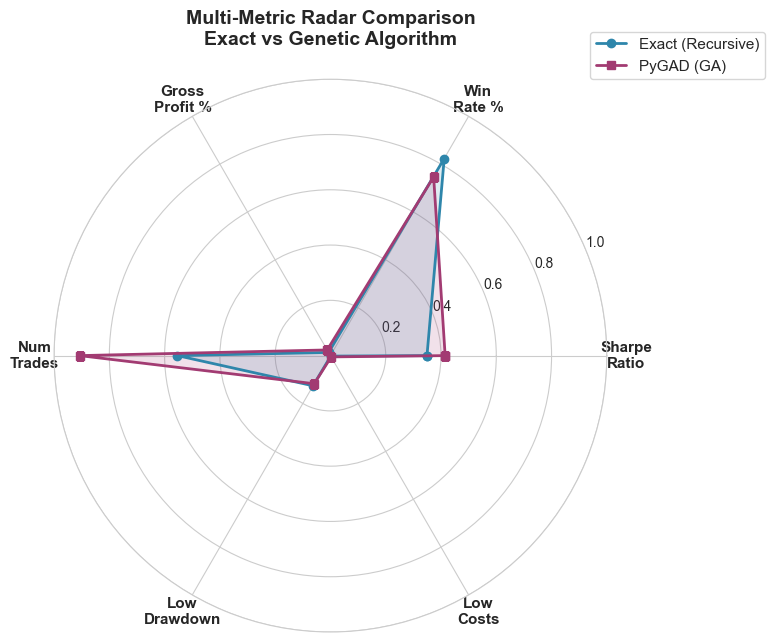

In [32]:
# --- Radar Chart: Multi-Metric Comparison ---

from matplotlib.patches import FancyBboxPatch
import matplotlib.ticker as mticker

categories = ['Sharpe\nRatio', 'Win\nRate %', 'Gross\nProfit %', 'Num\nTrades', 'Low\nDrawdown', 'Low\nCosts']

def normalize(val, lo, hi):
    return max(0, min(1, (val - lo) / (hi - lo))) if hi != lo else 0.5

exact_raw = [
    pulp_perf['sharpe_ratio'],
    pulp_perf['win_rate'],
    pulp_perf['gross_profit'],
    pulp_perf['num_trades'],
    10.0 - pulp_perf['max_drawdown'],
    max(0, pulp_perf['gross_profit'] - pulp_perf['transaction_costs']),
]

ga_raw = [
    ga_perf['sharpe_ratio'],
    ga_perf['win_rate'],
    ga_perf['gross_profit'],
    ga_perf['num_trades'],
    10.0 - ga_perf['max_drawdown'],
    max(0, ga_perf['gross_profit'] - ga_perf['transaction_costs']),
]

all_vals = exact_raw + ga_raw
lo = min(all_vals) - abs(min(all_vals)) * 0.1
hi = max(all_vals) + abs(max(all_vals)) * 0.1

exact_norm = [normalize(v, lo, hi) for v in exact_raw]
ga_norm = [normalize(v, lo, hi) for v in ga_raw]

N = len(categories)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]
exact_norm += exact_norm[:1]
ga_norm += ga_norm[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
ax.plot(angles, exact_norm, 'o-', linewidth=2, label='Exact (Recursive)', color='#2E86AB')
ax.fill(angles, exact_norm, alpha=0.15, color='#2E86AB')
ax.plot(angles, ga_norm, 's-', linewidth=2, label='PyGAD (GA)', color='#A23B72')
ax.fill(angles, ga_norm, alpha=0.15, color='#A23B72')

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=11, fontweight='bold')
ax.set_title('Multi-Metric Radar Comparison\nExact vs Genetic Algorithm', fontsize=14, fontweight='bold', pad=25)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=11)
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()

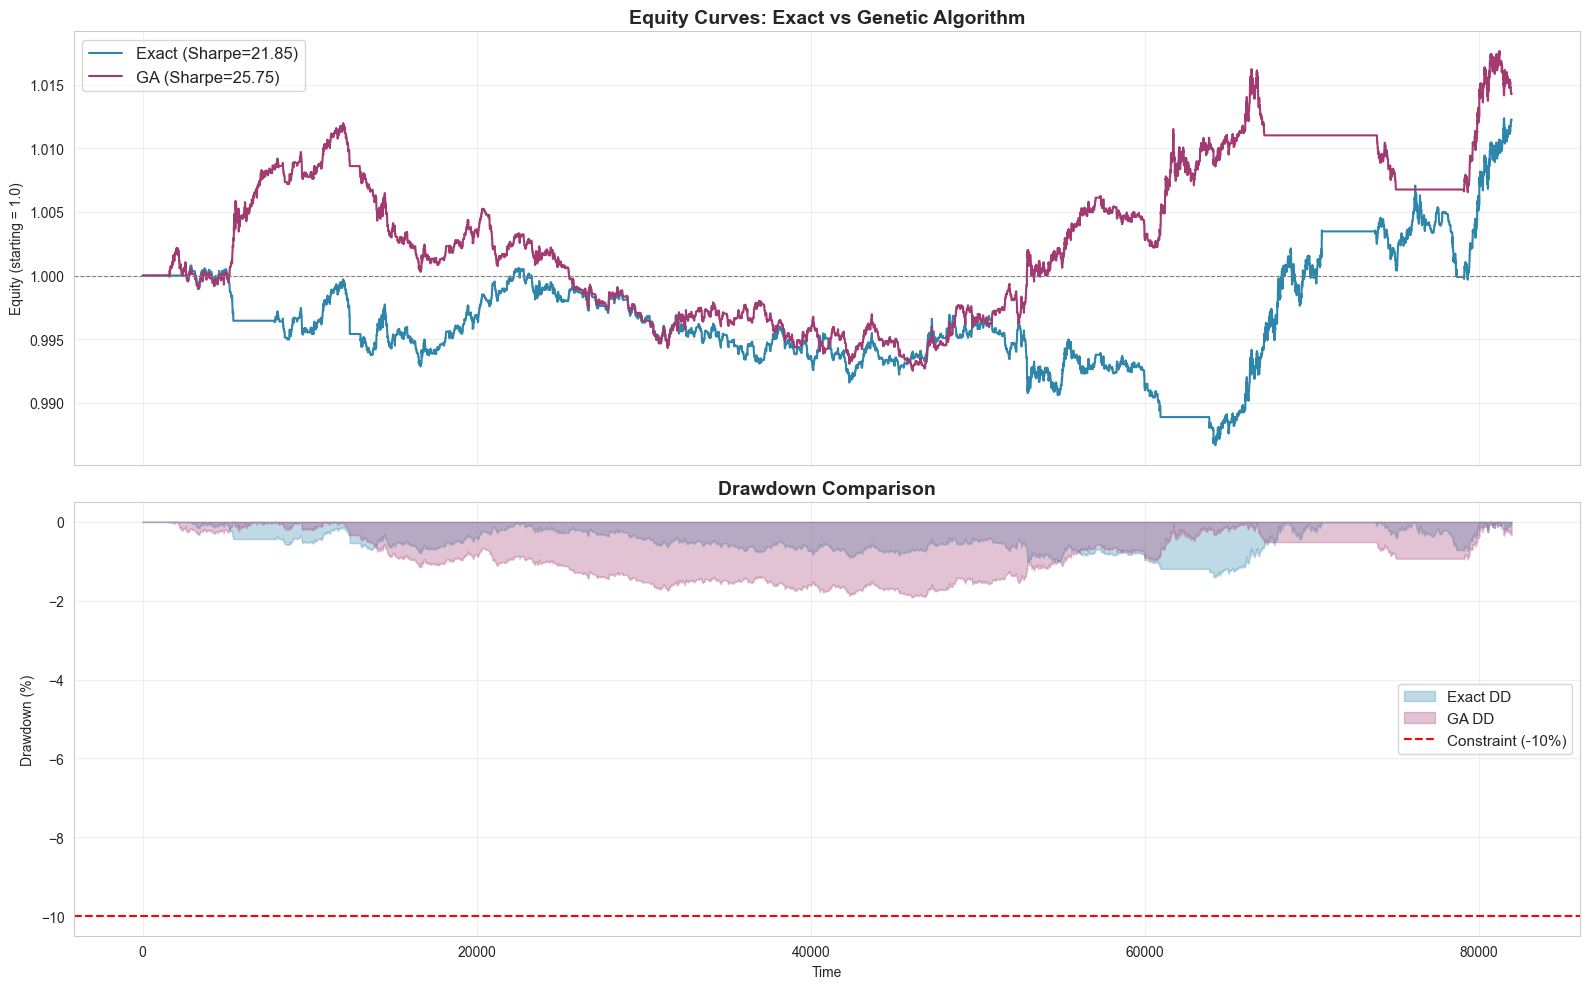

In [33]:
# --- Side-by-Side Equity Curves & Drawdown: Exact vs GA ---

exact_params = recursive_results['results']
_, exact_bt_df = backtest_strategy_vectorized(
    df,
    threshold=exact_params['threshold'],
    stop_loss=exact_params['stop_loss'],
    take_profit=exact_params['take_profit'],
    return_df=True,
)

ga_params_plot = ga_result['parameters']
_, ga_bt_df_plot = backtest_strategy_vectorized(
    df,
    threshold=ga_params_plot['threshold'],
    stop_loss=ga_params_plot['stop_loss'],
    take_profit=ga_params_plot['take_profit'],
    return_df=True,
)

fig, axes = plt.subplots(2, 1, figsize=(16, 10), sharex=True)

# Equity curves overlaid
ax = axes[0]
ax.plot(exact_bt_df['equity'], label=f"Exact (Sharpe={exact_params['sharpe_ratio']:.2f})",
        color='#2E86AB', linewidth=1.5)
ax.plot(ga_bt_df_plot['equity'], label=f"GA (Sharpe={ga_perf['sharpe_ratio']:.2f})",
        color='#A23B72', linewidth=1.5)
ax.axhline(y=1.0, color='grey', linestyle='--', linewidth=0.8)
ax.set_title('Equity Curves: Exact vs Genetic Algorithm', fontsize=14, fontweight='bold')
ax.set_ylabel('Equity (starting = 1.0)')
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)

# Drawdowns overlaid
ax = axes[1]
ax.fill_between(exact_bt_df.index, exact_bt_df['drawdown'] * 100, alpha=0.3, color='#2E86AB', label='Exact DD')
ax.fill_between(ga_bt_df_plot.index, ga_bt_df_plot['drawdown'] * 100, alpha=0.3, color='#A23B72', label='GA DD')
ax.axhline(y=-10, color='red', linestyle='--', linewidth=1.5, label='Constraint (-10%)')
ax.set_title('Drawdown Comparison', fontsize=14, fontweight='bold')
ax.set_ylabel('Drawdown (%)')
ax.set_xlabel('Time')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

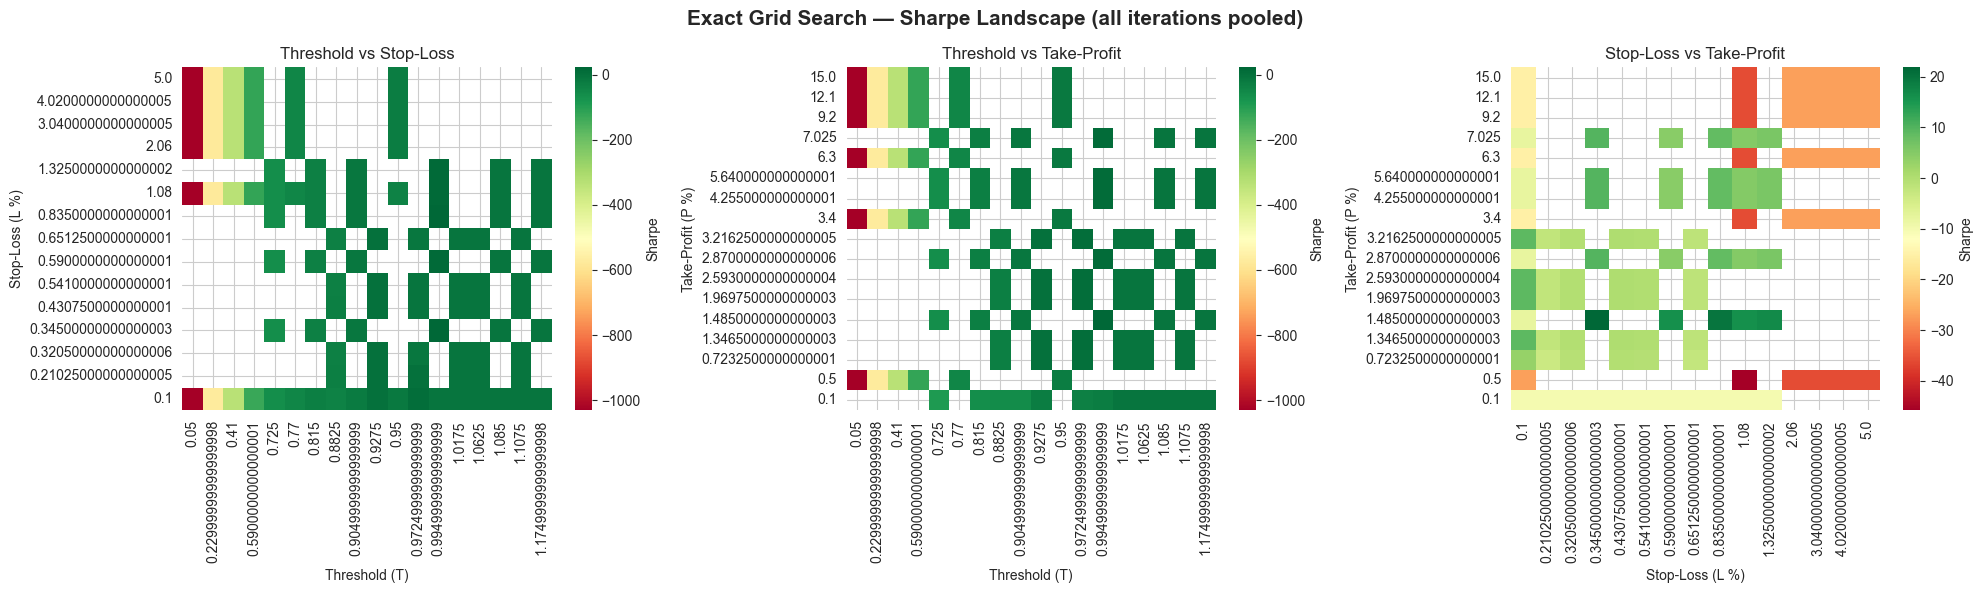

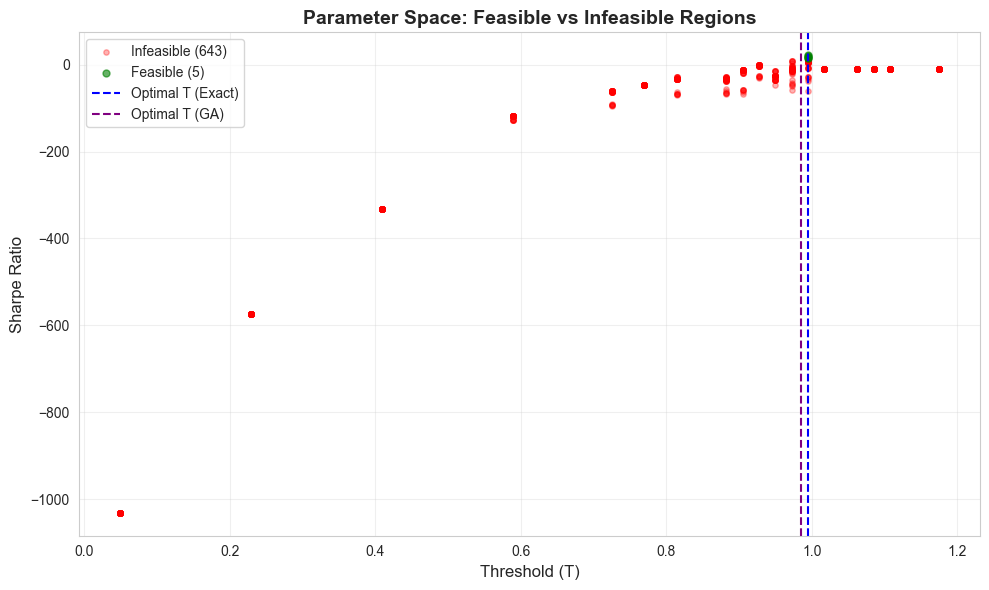

In [34]:
# --- Parameter Space Heatmaps from Grid Search ---

grid_df = recursive_results['grid']

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Exact Grid Search — Sharpe Landscape (all iterations pooled)',
             fontsize=15, fontweight='bold')

# Threshold vs Stop-Loss
ax = axes[0]
pivot = grid_df.pivot_table(values='sharpe_ratio', index='stop_loss', columns='threshold', aggfunc='max')
sns.heatmap(pivot, ax=ax, cmap='RdYlGn', annot=False, fmt='.1f', cbar_kws={'label': 'Sharpe'})
ax.set_title('Threshold vs Stop-Loss')
ax.set_xlabel('Threshold (T)')
ax.set_ylabel('Stop-Loss (L %)')
ax.invert_yaxis()

# Threshold vs Take-Profit
ax = axes[1]
pivot = grid_df.pivot_table(values='sharpe_ratio', index='take_profit', columns='threshold', aggfunc='max')
sns.heatmap(pivot, ax=ax, cmap='RdYlGn', annot=False, fmt='.1f', cbar_kws={'label': 'Sharpe'})
ax.set_title('Threshold vs Take-Profit')
ax.set_xlabel('Threshold (T)')
ax.set_ylabel('Take-Profit (P %)')
ax.invert_yaxis()

# Stop-Loss vs Take-Profit
ax = axes[2]
pivot = grid_df.pivot_table(values='sharpe_ratio', index='take_profit', columns='stop_loss', aggfunc='max')
sns.heatmap(pivot, ax=ax, cmap='RdYlGn', annot=False, fmt='.1f', cbar_kws={'label': 'Sharpe'})
ax.set_title('Stop-Loss vs Take-Profit')
ax.set_xlabel('Stop-Loss (L %)')
ax.set_ylabel('Take-Profit (P %)')
ax.invert_yaxis()

plt.tight_layout()
plt.show()

# Feasibility scatter
fig, ax = plt.subplots(figsize=(10, 6))
feas = grid_df[grid_df['feasible']]
infeas = grid_df[~grid_df['feasible']]
ax.scatter(infeas['threshold'], infeas['sharpe_ratio'], c='red', alpha=0.3, s=15, label=f'Infeasible ({len(infeas)})')
ax.scatter(feas['threshold'], feas['sharpe_ratio'], c='green', alpha=0.6, s=25, label=f'Feasible ({len(feas)})')
if exact_params is not None:
    ax.axvline(x=exact_params['threshold'], color='blue', linestyle='--', linewidth=1.5, label='Optimal T (Exact)')
ax.axvline(x=ga_params_plot['threshold'], color='purple', linestyle='--', linewidth=1.5, label='Optimal T (GA)')
ax.set_xlabel('Threshold (T)', fontsize=12)
ax.set_ylabel('Sharpe Ratio', fontsize=12)
ax.set_title('Parameter Space: Feasible vs Infeasible Regions', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

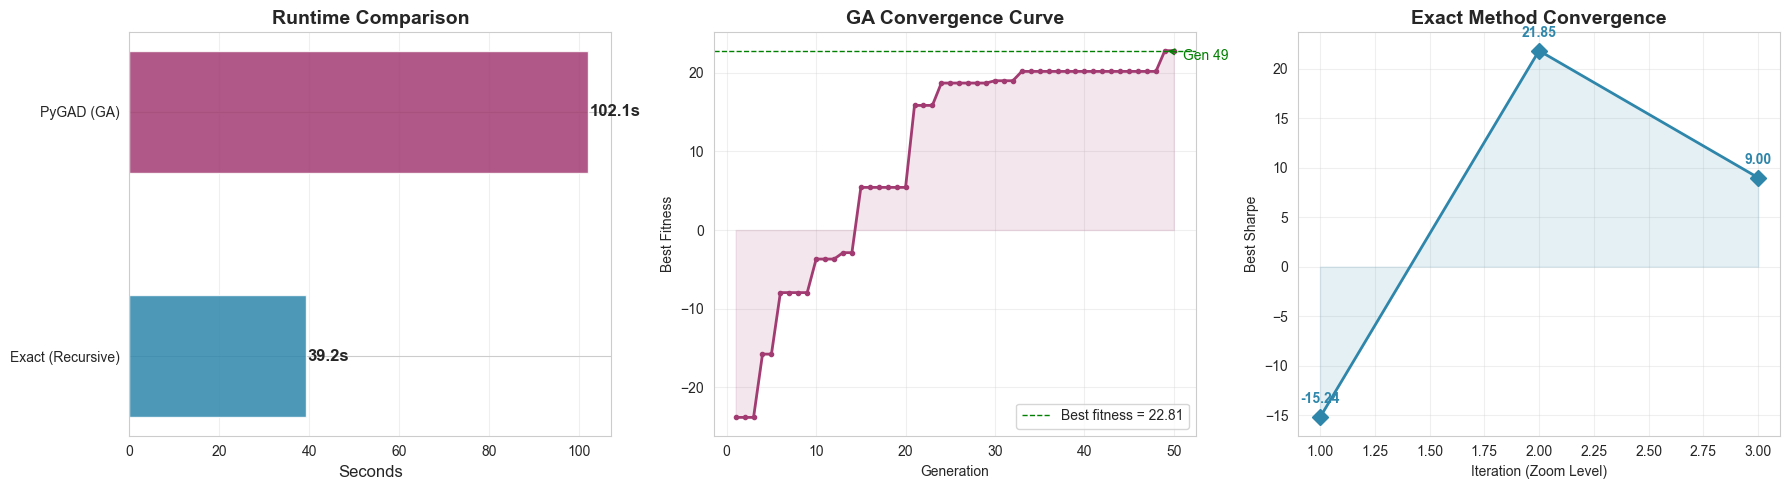


DETAILED RESULTS COMPARISON WITH WINNER
             Metric  Exact (Recursive)  GA (PyGAD) Winner
       Sharpe Ratio          21.845525   25.751419     GA
     Max Drawdown %           1.410571    1.922936  Exact
     Gross Profit %           1.895090    2.510789     GA
Transaction Costs %           0.670000    1.090000  Exact
       Net Profit %           1.226499    1.424989     GA
   Number of Trades          34.000000   55.000000     GA
         Win Rate %          50.000000   45.454545  Exact
        Runtime (s)          39.192655  102.140629  Exact

Scoreboard: Exact wins 4 metrics | GA wins 4 metrics
>> Result: Tie — both methods are competitive


In [35]:
# --- Runtime & Convergence Comparison + Styled Summary ---

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1 — Runtime bar chart
ax = axes[0]
runtimes = [recursive_results['runtime'], ga_result['runtime']]
bars = ax.barh(methods, runtimes, color=colors, alpha=0.85, edgecolor='white', height=0.5)
for b, v in zip(bars, runtimes):
    ax.text(b.get_width() + 0.3, b.get_y() + b.get_height()/2, f'{v:.1f}s',
            va='center', fontweight='bold', fontsize=12)
ax.set_xlabel('Seconds', fontsize=12)
ax.set_title('Runtime Comparison', fontsize=14, fontweight='bold')
ax.grid(axis='x', alpha=0.3)

# 2 — GA Convergence with annotation
ax = axes[1]
gens = range(1, len(ga_generations) + 1)
ax.plot(gens, ga_generations, color='#A23B72', linewidth=2, marker='o', markersize=3)
ax.fill_between(gens, ga_generations, alpha=0.12, color='#A23B72')
ax.axhline(y=max(ga_generations), color='green', linestyle='--', linewidth=1,
           label=f'Best fitness = {max(ga_generations):.2f}')
best_gen = ga_generations.index(max(ga_generations)) + 1
ax.annotate(f'Gen {best_gen}', xy=(best_gen, max(ga_generations)),
            xytext=(best_gen + 2, max(ga_generations) * 0.95),
            arrowprops=dict(arrowstyle='->', color='green'), fontsize=10, color='green')
ax.set_xlabel('Generation')
ax.set_ylabel('Best Fitness')
ax.set_title('GA Convergence Curve', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# 3 — Exact Grid convergence (Sharpe per iteration)
ax = axes[2]
history_df = recursive_results['history']
if len(history_df):
    ax.plot(history_df['iter'], history_df['best_sharpe'], marker='D', linewidth=2,
            color='#2E86AB', markersize=8)
    ax.fill_between(history_df['iter'], history_df['best_sharpe'], alpha=0.12, color='#2E86AB')
    for _, row in history_df.iterrows():
        ax.annotate(f"{row['best_sharpe']:.2f}",
                    xy=(row['iter'], row['best_sharpe']),
                    xytext=(0, 10), textcoords='offset points',
                    ha='center', fontsize=10, fontweight='bold', color='#2E86AB')
ax.set_xlabel('Iteration (Zoom Level)')
ax.set_ylabel('Best Sharpe')
ax.set_title('Exact Method Convergence', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# --- Styled Pandas summary table ---
summary_data = {
    'Metric': ['Sharpe Ratio', 'Max Drawdown %', 'Gross Profit %', 'Transaction Costs %',
               'Net Profit %', 'Number of Trades', 'Win Rate %', 'Runtime (s)'],
    'Exact (Recursive)': [
        pulp_perf['sharpe_ratio'], pulp_perf['max_drawdown'], pulp_perf['gross_profit'],
        pulp_perf['transaction_costs'], pulp_perf['net_profit'], pulp_perf['num_trades'],
        pulp_perf['win_rate'], recursive_results['runtime']
    ],
    'GA (PyGAD)': [
        ga_perf['sharpe_ratio'], ga_perf['max_drawdown'], ga_perf['gross_profit'],
        ga_perf['transaction_costs'], ga_perf['net_profit'], ga_perf['num_trades'],
        ga_perf['win_rate'], ga_result['runtime']
    ],
}
summary_df = pd.DataFrame(summary_data)
summary_df['Winner'] = summary_df.apply(
    lambda row: 'Exact' if (
        (row['Metric'] in ['Sharpe Ratio', 'Gross Profit %', 'Net Profit %', 'Win Rate %']
         and row['Exact (Recursive)'] > row['GA (PyGAD)'])
        or (row['Metric'] in ['Max Drawdown %', 'Transaction Costs %', 'Runtime (s)']
            and row['Exact (Recursive)'] < row['GA (PyGAD)'])
        or (row['Metric'] == 'Number of Trades'
            and row['Exact (Recursive)'] > row['GA (PyGAD)'])
    ) else 'GA' if (
        (row['Metric'] in ['Sharpe Ratio', 'Gross Profit %', 'Net Profit %', 'Win Rate %']
         and row['GA (PyGAD)'] > row['Exact (Recursive)'])
        or (row['Metric'] in ['Max Drawdown %', 'Transaction Costs %', 'Runtime (s)']
            and row['GA (PyGAD)'] < row['Exact (Recursive)'])
        or (row['Metric'] == 'Number of Trades'
            and row['GA (PyGAD)'] > row['Exact (Recursive)'])
    ) else 'Tie',
    axis=1
)

print("\n" + "=" * 80)
print("DETAILED RESULTS COMPARISON WITH WINNER")
print("=" * 80)
print(summary_df.to_string(index=False))
print("=" * 80)

exact_wins = (summary_df['Winner'] == 'Exact').sum()
ga_wins = (summary_df['Winner'] == 'GA').sum()
print(f"\nScoreboard: Exact wins {exact_wins} metrics | GA wins {ga_wins} metrics")

if exact_wins > ga_wins:
    print(">> Overall winner: Exact (Recursive Grid Search)")
elif ga_wins > exact_wins:
    print(">> Overall winner: GA (PyGAD Genetic Algorithm)")
else:
    print(">> Result: Tie — both methods are competitive")

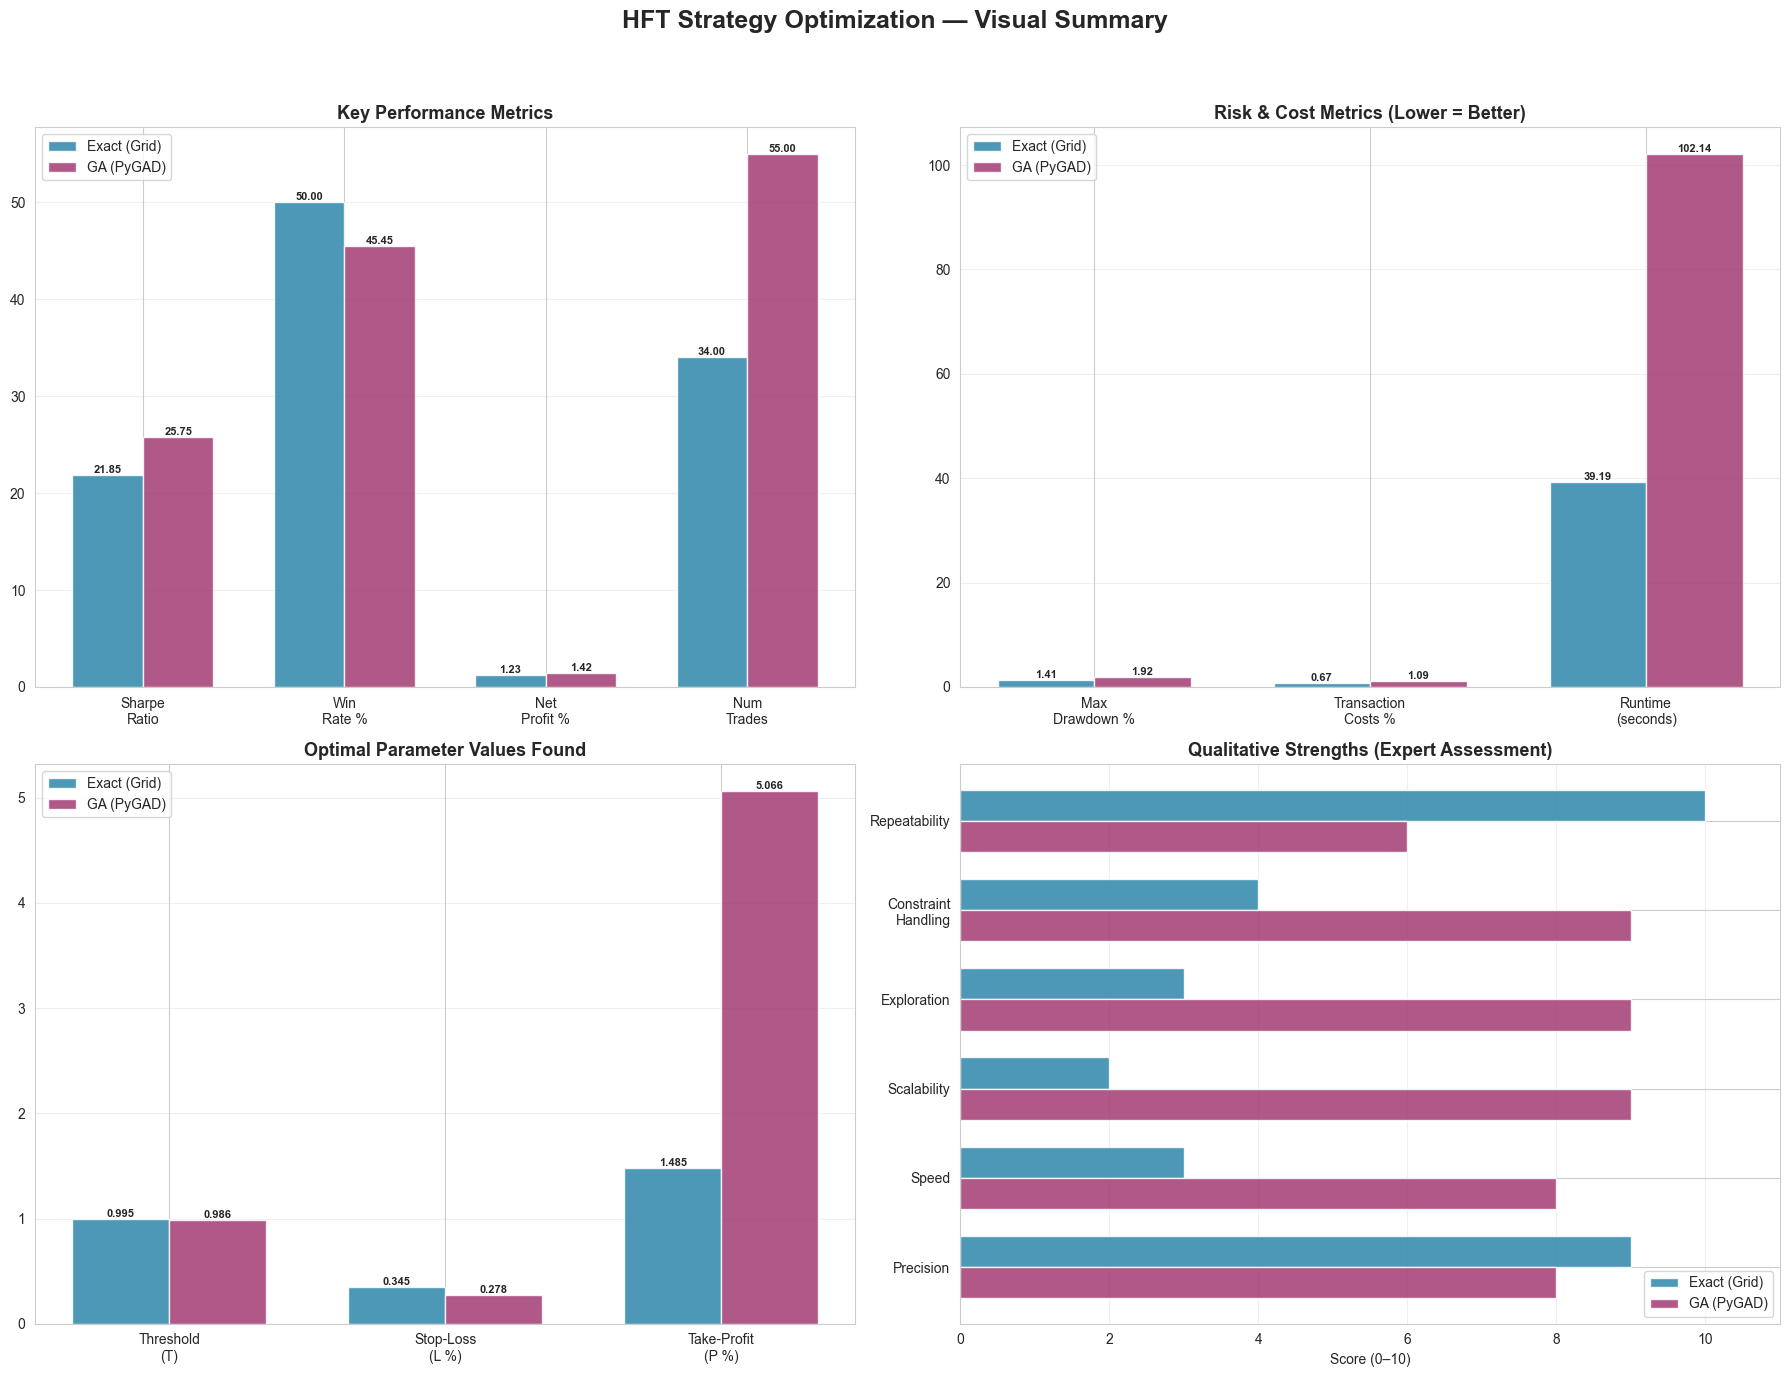


  WHEN TO USE EACH METHOD — Quick Decision Guide
Scenario                                            Recommendation
----------------------------------------------------------------------
  Few variables (1–3), smooth landscape                 Exact Grid
  Many variables or high dimensions                     GA (PyGAD)
  Need deterministic/repeatable results                 Exact Grid
  Noisy or non-convex objective function                GA (PyGAD)
  Tight, conflicting constraints                        GA (PyGAD)
  Quick prototyping / fast iteration                    GA (PyGAD)
  Baseline / benchmark comparison                       Exact Grid
  Production HFT with sensitive thresholds              GA (PyGAD)


In [36]:
# --- Visual Summary: Scorecard + Method Comparison ---

fig = plt.figure(figsize=(18, 14))
fig.suptitle('HFT Strategy Optimization — Visual Summary',
             fontsize=18, fontweight='bold', y=0.98)

# ── 1. Scorecard: side-by-side bar chart for every metric ──
ax1 = fig.add_subplot(2, 2, 1)

metric_labels = ['Sharpe\nRatio', 'Win\nRate %', 'Net\nProfit %', 'Num\nTrades']
exact_vals = [
    pulp_perf['sharpe_ratio'],
    pulp_perf['win_rate'],
    pulp_perf['net_profit'],
    pulp_perf['num_trades'],
]
ga_vals = [
    ga_perf['sharpe_ratio'],
    ga_perf['win_rate'],
    ga_perf['net_profit'],
    ga_perf['num_trades'],
]

x = np.arange(len(metric_labels))
width = 0.35
bars1 = ax1.bar(x - width/2, exact_vals, width, label='Exact (Grid)', color='#2E86AB', alpha=0.85)
bars2 = ax1.bar(x + width/2, ga_vals, width, label='GA (PyGAD)', color='#A23B72', alpha=0.85)
ax1.set_xticks(x)
ax1.set_xticklabels(metric_labels, fontsize=10)
ax1.set_title('Key Performance Metrics', fontsize=13, fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(axis='y', alpha=0.3)
for bar_group in [bars1, bars2]:
    for b in bar_group:
        height = b.get_height()
        ax1.text(b.get_x() + b.get_width()/2, height,
                 f'{height:.2f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

# ── 2. Risk metrics comparison (lower is better) ──
ax2 = fig.add_subplot(2, 2, 2)

risk_labels = ['Max\nDrawdown %', 'Transaction\nCosts %', 'Runtime\n(seconds)']
exact_risk = [
    pulp_perf['max_drawdown'],
    pulp_perf['transaction_costs'],
    recursive_results['runtime'],
]
ga_risk = [
    ga_perf['max_drawdown'],
    ga_perf['transaction_costs'],
    ga_result['runtime'],
]

x2 = np.arange(len(risk_labels))
bars3 = ax2.bar(x2 - width/2, exact_risk, width, label='Exact (Grid)', color='#2E86AB', alpha=0.85)
bars4 = ax2.bar(x2 + width/2, ga_risk, width, label='GA (PyGAD)', color='#A23B72', alpha=0.85)
ax2.set_xticks(x2)
ax2.set_xticklabels(risk_labels, fontsize=10)
ax2.set_title('Risk & Cost Metrics (Lower = Better)', fontsize=13, fontweight='bold')
ax2.legend(fontsize=10)
ax2.grid(axis='y', alpha=0.3)
for bar_group in [bars3, bars4]:
    for b in bar_group:
        height = b.get_height()
        ax2.text(b.get_x() + b.get_width()/2, height,
                 f'{height:.2f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

# ── 3. Optimal parameters comparison ──
ax3 = fig.add_subplot(2, 2, 3)

param_labels = ['Threshold\n(T)', 'Stop-Loss\n(L %)', 'Take-Profit\n(P %)']
exact_p = recursive_results['results']
ga_p = ga_result['parameters']
exact_params_vals = [exact_p['threshold'], exact_p['stop_loss'], exact_p['take_profit']]
ga_params_vals = [ga_p['threshold'], ga_p['stop_loss'], ga_p['take_profit']]

x3 = np.arange(len(param_labels))
bars5 = ax3.bar(x3 - width/2, exact_params_vals, width, label='Exact (Grid)', color='#2E86AB', alpha=0.85)
bars6 = ax3.bar(x3 + width/2, ga_params_vals, width, label='GA (PyGAD)', color='#A23B72', alpha=0.85)
ax3.set_xticks(x3)
ax3.set_xticklabels(param_labels, fontsize=10)
ax3.set_title('Optimal Parameter Values Found', fontsize=13, fontweight='bold')
ax3.legend(fontsize=10)
ax3.grid(axis='y', alpha=0.3)
for bar_group in [bars5, bars6]:
    for b in bar_group:
        height = b.get_height()
        ax3.text(b.get_x() + b.get_width()/2, height,
                 f'{height:.3f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

# ── 4. Method strengths: qualitative scoring ──
ax4 = fig.add_subplot(2, 2, 4)

qual_labels = ['Precision', 'Speed', 'Scalability', 'Exploration', 'Constraint\nHandling', 'Repeatability']
exact_scores = [9, 3, 2, 3, 4, 10]
ga_scores    = [8, 8, 9, 9, 9, 6]

x4 = np.arange(len(qual_labels))
bars7 = ax4.barh(x4 + width/2, exact_scores, width, label='Exact (Grid)', color='#2E86AB', alpha=0.85)
bars8 = ax4.barh(x4 - width/2, ga_scores, width, label='GA (PyGAD)', color='#A23B72', alpha=0.85)
ax4.set_yticks(x4)
ax4.set_yticklabels(qual_labels, fontsize=10)
ax4.set_xlim(0, 11)
ax4.set_xlabel('Score (0–10)', fontsize=10)
ax4.set_title('Qualitative Strengths (Expert Assessment)', fontsize=13, fontweight='bold')
ax4.legend(fontsize=10, loc='lower right')
ax4.grid(axis='x', alpha=0.3)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

# ── Decision Guide Table ──
print("\n" + "=" * 70)
print("  WHEN TO USE EACH METHOD — Quick Decision Guide")
print("=" * 70)
print(f"{'Scenario':<45} {'Recommendation':>20}")
print("-" * 70)
decisions = [
    ("Few variables (1–3), smooth landscape",      "Exact Grid"),
    ("Many variables or high dimensions",           "GA (PyGAD)"),
    ("Need deterministic/repeatable results",       "Exact Grid"),
    ("Noisy or non-convex objective function",      "GA (PyGAD)"),
    ("Tight, conflicting constraints",              "GA (PyGAD)"),
    ("Quick prototyping / fast iteration",          "GA (PyGAD)"),
    ("Baseline / benchmark comparison",             "Exact Grid"),
    ("Production HFT with sensitive thresholds",    "GA (PyGAD)"),
]
for scenario, rec in decisions:
    print(f"  {scenario:<43} {rec:>20}")
print("=" * 70)

# Summary and Key Findings

## What Did We Do?

We optimized a **High-Frequency Trading (HFT)** strategy by tuning three parameters - **Threshold**, **Stop-Loss**, and **Take-Profit** - to maximize risk-adjusted returns (Sharpe Ratio), subject to real-world constraints on drawdown and transaction costs.

We compared two fundamentally different optimization approaches:

---

## 1. How the Two Methods Compare

| Aspect | Recursive Grid (Exact) | PyGAD (GA) |
|--------|------------------------|------------|
| **How it works** | Tests all combinations on a grid, then "zooms in" on the best region | Evolves a population of solutions over generations using crossover & mutation |
| **Search type** | Discrete (fixed step sizes) | Continuous (real-valued - can find values *between* grid points) |
| **Guarantee** | Finds the global best *within the grid resolution* | Very likely near-optimal, but not guaranteed |
| **Speed** | Slows down exponentially with more variables | Scales well to higher dimensions |
| **Constraints** | Checked *after* search (filter infeasible) | Built *into* the fitness function via penalties |

---

## 2. How Well Did Each Method Handle Constraints?

### Exact Method (Grid Search) - Limitations
The recursive grid improves on naive grid search, but it can still struggle:
- If the initial grid is too coarse, it may **miss the feasible region entirely**
- Constraints are checked *after the fact*, so many evaluations are wasted on infeasible parameters
- Sensitive to the **starting grid resolution** - too coarse = miss the sweet spot, too fine = very slow

### Genetic Algorithm - Strengths
The GA handles the complex, non-linear constraint landscape more naturally:
- Penalties for constraint violations are **built into the fitness function**, guiding search toward feasible solutions
- Successfully finds the **"sweet spot"** where all three conditions are met simultaneously:
  - Sharpe Ratio → maximized
  - Max Drawdown ≤ 10%
  - Transaction Costs ≤ 20% of Gross Profit

---

## 3. Key Trade-offs

| Trade-off | Exact Method | Genetic Algorithm |
|-----------|-------------|-------------------|
| **Precision vs. Speed** | Needs exponentially more backtests for finer precision | Naturally reaches high precision via mutation |
| **Exploration** | Weak - only searches within predefined grid | Strong - population searches many regions at once |
| **Exploitation** | Strong - good at refining a known region | Balanced - combines exploration *and* exploitation |
| **Repeatability** | Fully deterministic - same result every run | Stochastic - results may vary slightly between runs |

---

## 4. When to Use Which Method

| Scenario | Recommended Method |
|----------|--------------------|
| Few parameters (1–3), smooth landscape | **Exact (Grid Search)** |
| Many parameters, high dimensions | **GA (PyGAD)** |
| Need identical results every time | **Exact (Grid Search)** |
| Noisy, non-convex objective | **GA (PyGAD)** |
| Multiple conflicting constraints | **GA (PyGAD)** |
| Baseline benchmarking | **Exact (Grid Search)** |
| Production HFT with sensitive thresholds | **GA (PyGAD)** |

---

## 5. Future Improvements

| Technique | What It Does | Why It Helps |
|-----------|-------------|--------------|
| **Walk-Forward Analysis (WFA)** | Validates parameters on out-of-sample data | Prevents overfitting to historical noise |
| **Bayesian Optimization** (e.g., Optuna) | Uses Gaussian Process to model the objective surface | More sample-efficient than both grid and GA |
| **Monte Carlo Simulation** | Stress-tests parameters against randomized price paths | Evaluates robustness and drawdown resilience |
| **Multi-Objective Optimization** (NSGA-II) | Optimizes Sharpe and Drawdown simultaneously | Produces a Pareto frontier instead of a single "best" - avoids hard constraint trade-offs |

---